<a href="https://colab.research.google.com/github/gtzan/synthesizers_cs_perspective/blob/main/Explaining_the_DFT_a_music_perspective_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A music and sound exposition of the Discrete Fourier Transform
## George Tzanetakis - Department of Computer Science, University of Victoria

The Discrete Fourier Transform (DFT) is fundamental for any type of music and sound processing using computers. The goal of this notebook is to develop high-level intuition behind the concepts that underlie the DFT and understand how this transformation is used by various algorithms for audio analysis and synthesis. The intended audience is anyone with some knowledge of high school math that is interested in the topic. This is not a detailed mathematical digital signal processing (DSP) exposition. At the end of the notebook a variety of resources for better understanding the DFT and audio processing are provided for further digging.

There are many great resources for understanding the DFT including textbooks, tutorial articles, and videos some of which are listed at the end of this exposition. This material reflects my own personal way of teaching the DFT that has evolved over twenty years of experience with striving to explain the underlying concepts to students from diverse academic backgrounds and disciplines with a focus on how it connects to music information retrieval.



# PART 1 Synthesizing sounds and melodies using sinusoids

## Sinusoids as mathematical abstractions for understanding sound

A sinusoid is a type of continuous curve with a specific repeating shape. It is a mathematical abstraction that can help us reason about a variety of real-world phenomena. It is an idealization similarly to how a circle or an infinite line are mathematical abstractions that can help us solve concrete problems in physical gemotry. Real-word signals don't last forever and in many cases are discrete in nature. For example, audio signals are changes in air pressure created by disturbing a large but finite number of air molecules and have a finite duration. It is important to keep in mind that sinusoidal signals are conceptual abstractions as this will inform us about both the advantages of using them as well as their limitations when modeling actual audio signals.

The equation for a continuous sinusoid is:
$$
f(t) = \alpha sin(\omega t + \phi)\;\;\;\; \text{with} \;\;\;   -\infty < t < +\infty
$$

A **sinusoid** is a function of a continuous variable $t$ representing time. Each sinusoid is uniquely characterized by three numbers: the amplitude $\alpha$, the frequency $\omega$, and the phase $\phi$. The notation and the units of measurement of each number can change but it is important to keep in mind for the rest of the exposition that each sinusoidal signal is characterized uniquely by these three real numbers numbers.

## Sampling and Quantization

Our goal is to process audio signals using computers. Computers need to operate on discrete numerical values that are represented by a finite number of bits. Sampling refers to the process of taking measurements of the signal under consideration at discrete regular time intervals (for example we can sample/measure the temperature of a lake every 1 hour). For each time instance we have a corrsesponding measurement of the value of the signal. This measurement needs to be represented using a set of discrete values represented using a finite number of bits. As an example, a compact disc stores digital audio samples at a sampling rate of 44100 samples/second and each sample is represented as an 16-bit integer. For the remaining of the notebook, we will be working with audio signals with values represented as floating point numbers between -1.0 and 1.0 as this make audio processing easier. We will also be showing plots that look as if the underlying signal is continuous so it is useful to keep in mind that the actual representation is discrete arrays of audio samples as shown in the plot of the sinusoids with stems on each value shown below.



## Playing and plotting a sinusoid signal

So after sampling and quantization we can represent sinusoids (and as we will see any other sound) as very large array of floating point numbers between -1.0 and 1.0. We can generate some samples (corresponding to a specific duration) of a sinusoid of a particular frequency and then see view the corresponding plot. In the example below I use a very low sampling rate (compared to audio sampling rates) so that we can show with plots the difference between the continuous curve plotting that we will be using and contrast it with the more accurate stem plot that shows each individual audio sample.

In [ ]:
%%capture

!pip install jupyter-to-medium


In [ ]:

import numpy as np
import IPython.display as ipd
import librosa
%matplotlib inline
import logging
import matplotlib.pyplot as plt
# Silence the font manager logging system
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# xkcd style plots and suppress font warnings
plt.xkcd()

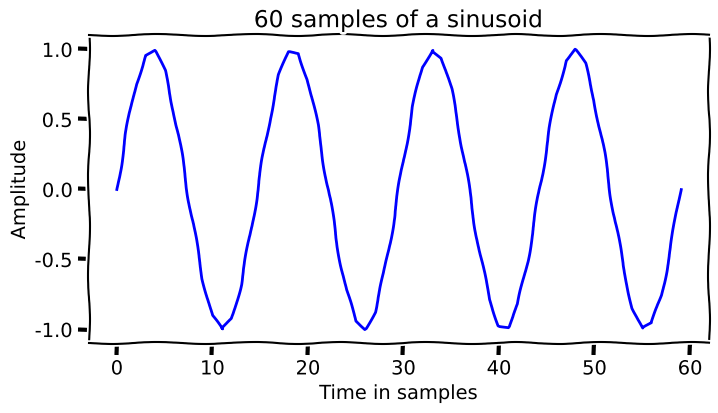

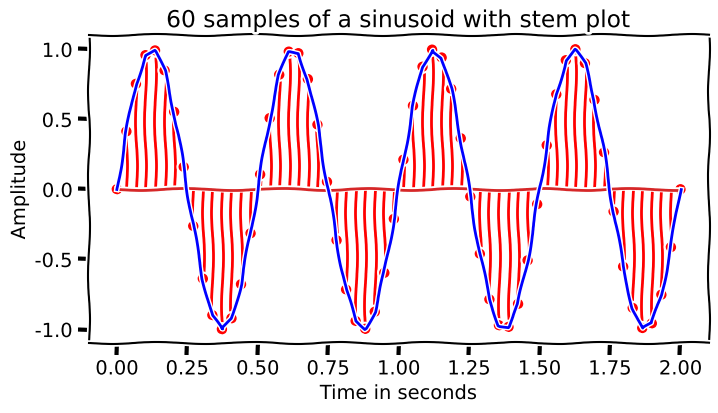

In [ ]:

srate = 30         # sampling rate 30 samples a second
duration = 2       # duration in seconds
freq = 2           # frequency in Hz

t = np.linspace(0,duration,srate*duration)     # time instances of samples
data =  np.sin(2*np.pi*freq*t);                # audio samples

fig = plt.figure(figsize=(8,4))
plt.xlabel("Time in samples")
plt.ylabel("Amplitude")
plt.title("60 samples of a sinusoid")
plt.plot(data[0:120], lw=2, color='blue')
fig = plt.figure(figsize=(8,4))
plt.xlabel("Time in seconds")
plt.ylabel("Amplitude")
plt.title("60 samples of a sinusoid with stem plot")
plt.stem(t[0:120],data[0:120], 'r', )
plt.plot(t[0:120], data[0:120], color='blue')
plt.show()




Now let's create a sinusoidal sound of a specific duration with more realistic parameters for sampling rate, frequency, and duration that we can actuallty hear.

In [ ]:
srate = 22050      # sampling rate
duration = 2       # duration in seconds
freq = 440         # frequency in herz

t = np.linspace(0,duration,srate*duration)     # time instances of samples
data =  np.sin(2*np.pi*freq*t);                # audio samples

# play the corresponding audio (normalize=False stops the playback utility from
# normalizing the audio i.e making
# the largest sample equal to 1.0
ipd.Audio(data,rate=srate, normalize=False)

In [ ]:
# Let's use the code above to create a function that will return an array of
# time points and the corresponding audio samples

def generate_sinusoid(amp = 1.0, freq = 440.0, phase=0.0, dur = 1.0, srate =srate):
  t = np.linspace(0,dur, int(srate* dur))
  data = amp * np.sin(2*np.pi*freq*t+phase)
  return (t,data)

(t,audio) = generate_sinusoid(amp=1.0, freq=220.0, phase=0.0, dur=2.0)
ipd.Audio(audio, rate=srate, normalize=False)


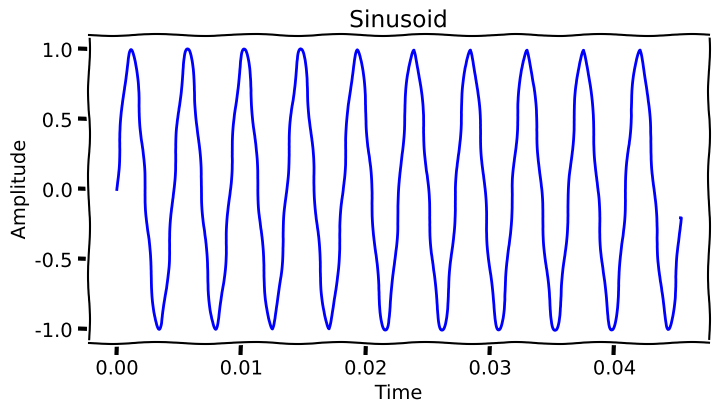

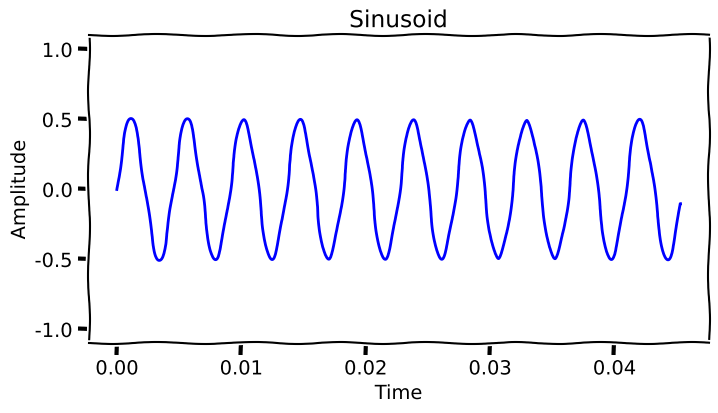

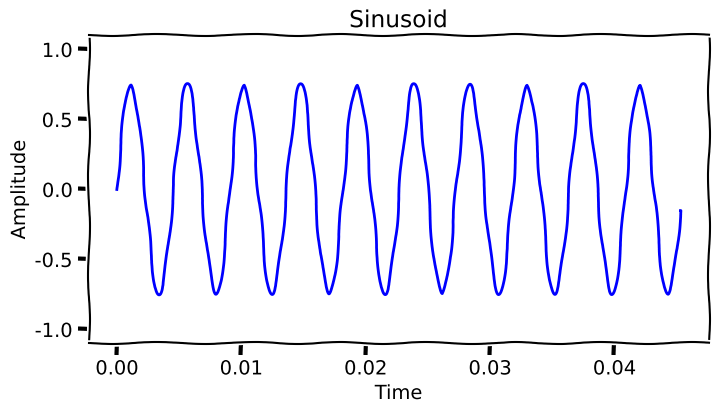

In [ ]:
def plot_samples(t, data, start_samples = 0, end_samples = 1000, xlabel="Time", ylabel="Amplitude", title="Sinusoid"):
  fig = plt.figure(figsize=(8,4))
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.title(title)
  plt.ylim(-1.1, 1.1) # set the upper and lower limit of the plot

  plt.plot(t[start_samples:end_samples], data[start_samples:end_samples], lw=2, color='blue')
  plt.show()

# create sinusoids with a different amplitudes but the same frequency
(t,audio2) = generate_sinusoid(amp=0.5, freq=220.0, dur=2.0, phase=0.0)
(t,audio3) = generate_sinusoid(amp = 0.75, freq=220)
plot_samples(t, audio)
plot_samples(t, audio2)
plot_samples(t,audio3)

## Playing a simple melody using sinusoids

Sinusoids are theoretically infinite signals but we can calculate the samples for a finite duration as we have been doing. By appropriately setting up frequencies and amplitudes we can create recognizable melodies i.e sequences of what are called pitches or notes in music theory. For example we can set
the frequencies of the notes called C, D, and E in Western music.
The details of how specific frequencies are mapped top discrete labels called pitches is a complex and fascinating topic and it involves the creation of what are called tuning systems. You can experiment with changing the durations and order of the notes and listen to how it affects how you hear the corresponding melody.

In [ ]:
# frequencies of three notes (C, D, E)
c_freq = 523.0
d_freq = 587.0
e_freq = 659.0

# generate sine signals corresponding to each note
(t,c_data) = generate_sinusoid(freq = c_freq, dur = 0.5, amp = 0.5, srate = srate)
(t,d_data) = generate_sinusoid(freq = d_freq, dur = 0.5, amp = 0.5)
(t,e_data) = generate_sinusoid(freq = e_freq, dur = 0.5, amp = 0.5)

# form a simple melody by concateneting the signal arrays for each note
melody = np.hstack([c_data, d_data, e_data, c_data, c_data, d_data, e_data, c_data])
ipd.Audio(melody,rate=srate, normalize=False)

## Side note - Amplitude Envelopes

In [ ]:
import numpy as np

def generate_adsr_envelope(dur, attack_pct, decay_pct, sustain_level, release_pct, srate=44100):
    # 1. Validate that the combined percentage stages do not exceed 100% (1.0)
    adr_sum = attack_pct + decay_pct + release_pct
    if adr_sum > 1.0:
        raise ValueError(
            f"The sum of Attack, Decay, and Release percentages ({adr_sum * 100:.1f}%) "
            f"cannot exceed 100%."
        )
    sustain_pct = 1.0 - adr_sum
    total_samples = int(dur * srate)

    # setup number of samples for each stage
    a_samples = int(attack_pct * total_samples)
    d_samples = int(decay_pct * total_samples)
    r_samples = int(release_pct * total_samples)
    s_samples = total_samples - (a_samples + d_samples + r_samples)

    # calculate ramps
    attack_stage = np.linspace(0.0, 1.0, a_samples, endpoint=False)
    decay_stage = np.linspace(1.0, sustain_level, d_samples, endpoint=False)
    sustain_stage = np.full(s_samples, sustain_level)
    release_stage = np.linspace(sustain_level, 0.0, r_samples, endpoint=True)

    envelope = np.concatenate([attack_stage, decay_stage, sustain_stage, release_stage])
    return envelope

ENVELOPE_PRESETS = {
    "bass":    {"attack_pct": 0.00, "decay_pct": 0.30, "sustain_level": 0.0, "release_pct": 0.70},
    "pad": {"attack_pct": 0.25, "decay_pct": 0.15, "sustain_level": 0.7, "release_pct": 0.35},
    "pluck": {"attack_pct": 0.05, "decay_pct": 0.10, "sustain_level": 0.8, "release_pct": 0.10}
}

PITCH_PRESETS = {
    "bass": 32.70,   # Note: C1 (Deep, physical sub-bass)
    "pad": 440.00, # Note: A4 (Clear, warm mid-range)
    "pluck": 1046.50 # Note: C6 (Bright, piercing high-range)
}

(t,bass_data) = generate_sinusoid(freq = PITCH_PRESETS["bass"], dur = 1.5, amp = 0.5, srate = srate)
(t,mid_data)  = generate_sinusoid(freq = PITCH_PRESETS["pad"], dur = 2, amp = 0.5)
(t,high_data)  = generate_sinusoid(freq = PITCH_PRESETS["pluck"], dur = 0.6, amp = 0.5)

audio = np.hstack([bass_data, mid_data, high_data])
ipd.Audio(audio,rate=srate, normalize=False)


In [ ]:
bass_envelope = generate_adsr_envelope(dur=1.5, **ENVELOPE_PRESETS["bass"], srate=srate)
mid_envelope = generate_adsr_envelope(dur=2, **ENVELOPE_PRESETS["pad"], srate=srate)
high_envelope = generate_adsr_envelope(dur=0.6, **ENVELOPE_PRESETS["pluck"], srate=srate)

bass_data = bass_data * bass_envelope
mid_data = mid_data * mid_envelope
high_data = high_data * high_envelope

audio = np.hstack([bass_data, mid_data, high_data])
ipd.Audio(audio,rate=srate, normalize=False)


In [ ]:
import numpy as np
import IPython.display as ipd

# -------------------------------------------------------------------------
# 1. Structural Setup & Presets
# -------------------------------------------------------------------------
sample_rate = 44100
bpm = 120
beat_duration = 60.0 / bpm             # 0.5 seconds per beat
total_beats = 8
total_duration = total_beats * beat_duration  # 4.0 seconds total tracking
total_samples = int(total_duration * sample_rate)

PITCH_PRESETS = {
    "sub_bass": 65.40,     # C1
    "ambient_pad": 392.0, # C4 (Lowered slightly for a thicker pad chord)
    "retro_pluck": 1046.50 # C6
}

ENVELOPE_PRESETS = {
    "sub_bass":    {"attack_pct": 0.00, "decay_pct": 0.30, "sustain_level": 0.0, "release_pct": 0.70},
    "ambient_pad": {"attack_pct": 0.25, "decay_pct": 0.15, "sustain_level": 0.7, "release_pct": 0.35},
    "retro_pluck": {"attack_pct": 0.05, "decay_pct": 0.10, "sustain_level": 0.8, "release_pct": 0.10}
}


def add_note(amp, timeline, start_beat, duration_beats, frequency, envelope_type):
    # Calculate timeline index positions
    start_sample = int(start_beat * beat_duration * sample_rate)
    note_duration_sec = duration_beats * beat_duration
    note_samples = int(note_duration_sec * sample_rate)

    # Generate raw tone and apply its target ADSR profile
    t = np.linspace(0, note_duration_sec, note_samples, endpoint=False)
    sine_wave = np.sin(2 * np.pi * frequency * t)
    envelope = generate_adsr_envelope(
        dur=note_duration_sec,
        srate=sample_rate,
        **ENVELOPE_PRESETS[envelope_type]
    )
    timeline[start_sample : start_sample + note_samples] += amp * (sine_wave * envelope)

song_timeline = np.zeros(total_samples)

# Layer 1: Ambient Pad (Swells once over the full 8 beats)
add_note(0.1, song_timeline, start_beat=0, duration_beats=8, frequency=PITCH_PRESETS["ambient_pad"], envelope_type="ambient_pad")

# Layer 2: The Sub-Bass Kick (Hits on every beat)
for beat in [0, 1, 2, 3, 4, 5, 6, 7]:
    add_note(1.0, song_timeline, start_beat=beat, duration_beats=1, frequency=PITCH_PRESETS["sub_bass"], envelope_type="sub_bass")


def midi_to_freq(midi_note):
    """Converts a standard MIDI note integer into a precise frequency in Hz."""
    if midi_note == 0:  # Use 0 to denote a rest (silence)
        return 0.0
    return 440.0 * (2.0 ** ((midi_note - 69) / 12.0))

melody_score = [
    (79, 0, 2),    # G5
    (74, 2, 1),    # D5
    (75, 3, 1),    # D#5 (Characteristic Minor 3rd of C)
    (77, 4, 2),    # F5
    (75, 6, 1),    # D#5
    (74, 7, 1),    # D5
    (72, 8, 2),    # C5 (New Tonic Resolution)
    (72, 10, 1),   # C5
    (75, 11, 1),   # D#5
    (79, 12, 2),   # G5
    (77, 14, 1),   # F5
    (75, 15, 1)    # D#5
]


# Layer 3: The Retro Pluck Melody (Rapid Arpeggio climbing up the C-chord scale)
# Multipliers scale the root C6 pitch up through a classic arcade arpeggio
melody = [79, 79, 74, 75, 77, 75, 74, 72, 72, 75, 79, 77, 75]
# melody_scale_multipliers = [1.0, 1.2, 1.5, 1.2, 1.0, 1.2, 1.5, 2.0, 1.0, 1.2, 1.5, 1.2, 1.5, 2.0, 1.0, 1.2, 1.2, 1.2, 1.2,1.5, 1.5, 1.2, 1.2 ]
for beat in range(len(melody)):
  freq_mod = midi_to_freq(melody[beat])
  add_note(0.2, song_timeline, start_beat=beat/4, duration_beats=0.3, frequency=freq_mod, envelope_type="retro_pluck")

# -------------------------------------------------------------------------
# 4. Mix-bus Limiter & Rendering
# -------------------------------------------------------------------------
# Normalize the final signal to 0.85 max amplitude to prevent mixed track clipping
song_timeline = (song_timeline / np.max(np.abs(song_timeline))) * 0.85

# Output the interactive song player widget
ipd.Audio(song_timeline, rate=srate)


## Adding sinusoidal signals

Sinusoidal signals can be added together. The resulting signal is also infinite and periodic but will have a different shape. Let's listen and plot some linear combinations of sinusoids. For certain combinations of frequencies our ear hears a single complex sound rather than the individual sinusoids that are played together. This is called additive synthesis. As we will later see, any complex sound can be modelled as an addition of multiple sinusoids with appropriate values for the frequencies, durations, amplitudes, and phases. In the example below you can hear how the combination of three sinusoids sounds. These sinusoids are **harmonically related ** which means that their corresponding frequencies are all multiples of the same frequency which is called the **fundamental**.



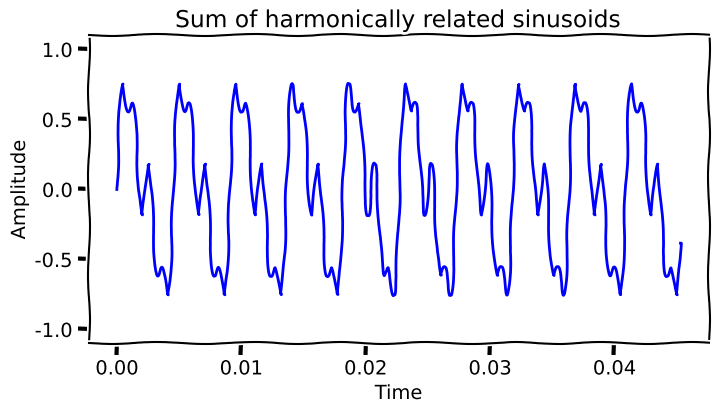

In [ ]:
(t,s1) = generate_sinusoid(amp = 0.6, freq = 220.0, dur = 1.0, phase = 0)
(t,s2) = generate_sinusoid(amp = 0.3, freq = 440.0, dur = 1.0, phase = 0)
(t,s3) = generate_sinusoid(amp = 0.2, freq = 880.0, dur = 1.0, phase = 0)

s = np.concatenate([s1+s2+s3, s1+s2, s1], axis=0)
plot_samples(t,s, title="Sum of harmonically related sinusoids")
ipd.Audio(s, rate=srate, normalize=False)





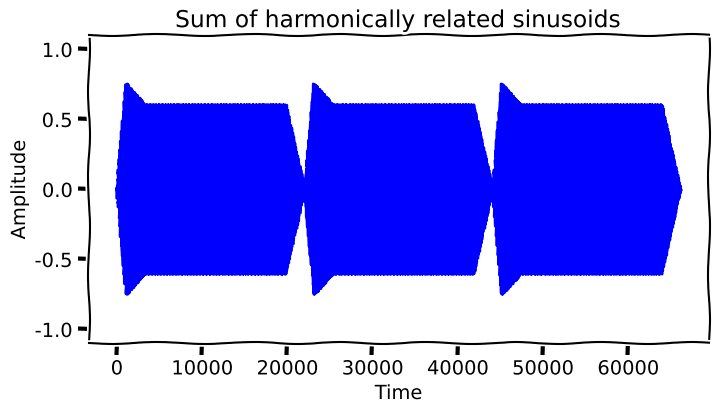

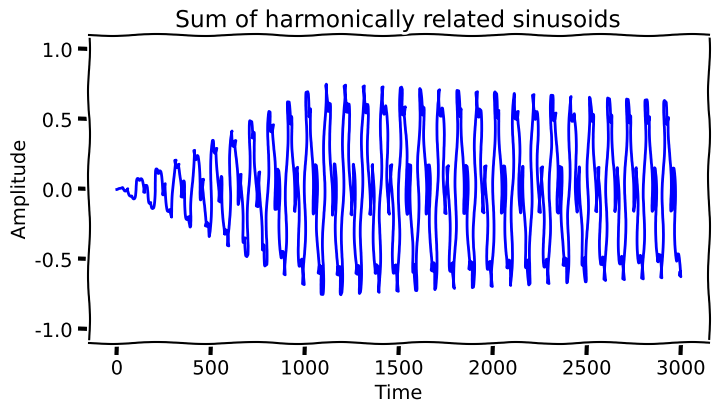

In [ ]:
env = generate_adsr_envelope(dur=1.0, **ENVELOPE_PRESETS["retro_pluck"], srate=srate)
n1 = (s1+s2+s3) * env
n = np.concatenate([n1, n1, n1], axis=0)
plot_samples(np.arange(len(n)),n, end_samples = 3*srate, title="Sum of harmonically related sinusoids")
plot_samples(np.arange(len(n)),n, end_samples = 3000, title="Sum of harmonically related sinusoids")

ipd.Audio(n, rate=srate, normalize=False)


When the sinusoids being added are not harmonically related - one can hear more clearly the individual sinusoids in the combined sound and the combined sound is more complex and harsher than when they are harmonically related. You can experiment with the amplitudes and frequencies to see how the resulting sound is affected.

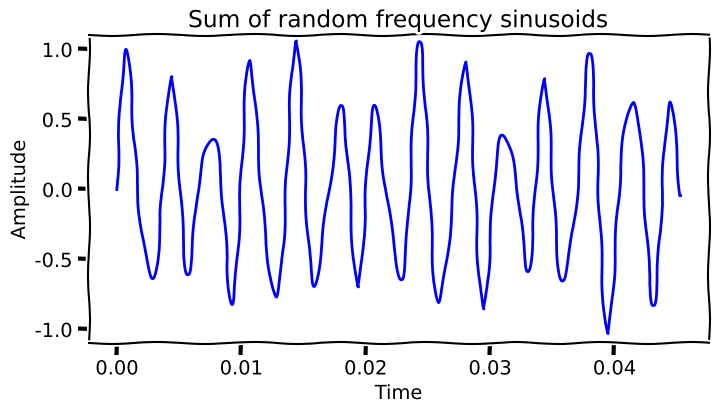

In [ ]:
(t,s1) = generate_sinusoid(amp = 0.2, freq = 220.0, dur = 2.0, phase = 0)
(t,s2) = generate_sinusoid(amp = 0.7, freq = 297.0, dur = 2.0, phase = 0)
(t,s3) = generate_sinusoid(amp = 0.2, freq = 503.0, dur = 2.0, phase = 0)

s = np.concatenate([s1+s2+s3, s1+s2, s1], axis=0)
plot_samples(t,s, title="Sum of random frequency sinusoids")
ipd.Audio(s, rate=srate)

In [ ]:
import numpy as np
import IPython.display as ipd

def generate_rich_bell(root_frequency, duration_sec=5.0, sample_rate=44100):
    """
    Synthesizes a rich bell sound using inharmonic additive synthesis
    and unique per-partial decay envelopes.
    """
    total_samples = int(duration_sec * sample_rate)
    bell_signal = np.zeros(total_samples)
    t = np.linspace(0, duration_sec, total_samples, endpoint=False)

    # Define the 6 partials: (Frequency Multiplier, Relative Amplitude/Volume)
    # Note the inharmonic 1.19 (minor 3rd) and 4.1 (high strike ping)
    partials_config = [
        {"mult": 0.5,  "amp": 0.5,  "env": {"attack_pct": 0.01, "decay_pct": 0.50, "sustain_level": 0.0, "release_pct": 0.49}}, # Hum
        {"mult": 1.0,  "amp": 1.0,  "env": {"attack_pct": 0.00, "decay_pct": 0.40, "sustain_level": 0.0, "release_pct": 0.60}}, # Fundamental
        {"mult": 1.19, "amp": 0.6,  "env": {"attack_pct": 0.00, "decay_pct": 0.30, "sustain_level": 0.0, "release_pct": 0.70}}, # Minor 3rd
        {"mult": 1.5,  "amp": 0.4,  "env": {"attack_pct": 0.00, "decay_pct": 0.25, "sustain_level": 0.0, "release_pct": 0.75}}, # Fifth
        {"mult": 2.0,  "amp": 0.5,  "env": {"attack_pct": 0.00, "decay_pct": 0.20, "sustain_level": 0.0, "release_pct": 0.80}}, # Octave
        {"mult": 4.1,  "amp": 0.7,  "env": {"attack_pct": 0.00, "decay_pct": 0.05, "sustain_level": 0.0, "release_pct": 0.95}}  # High Strike
    ]

    # Render and sum each partial layer
    for p in partials_config:
        freq = root_frequency * p["mult"]
        raw_sine = np.sin(2 * np.pi * freq * t)

        # Generate the specific envelope for this frequency component
        envelope = generate_adsr_percentage_envelope(
            total_duration_sec=duration_sec,
            sample_rate=sample_rate,
            **p["env"]
        )

        # Add the weighted partial to the combined signal
        bell_signal += raw_sine * envelope * p["amp"]

    # Standardize amplitude to avoid digital clipping distortion
    bell_signal = (bell_signal / np.max(np.abs(bell_signal))) * 0.85
    return bell_signal

# --- Execution ---
sample_rate = 44100
# Generate a resonant A4 Bell spanning a 6.0 second decay trail
rendered_bell1 = generate_rich_bell(root_frequency=329.00, duration_sec=3.0, sample_rate=sample_rate)
rendered_bell2 = generate_rich_bell(root_frequency=261.00, duration_sec=2.0, sample_rate=sample_rate)
rendered_bell3 = generate_rich_bell(root_frequency=196.00, duration_sec=2.0, sample_rate=sample_rate)
rendered_bell = np.concatenate([rendered_bell1, rendered_bell2, rendered_bell3, rendered_bell3])
ipd.Audio(rendered_bell, rate=sample_rate)


## Sinusoids as building blocks

So as a first observation we notice that we can get more complex sounds by adding sinusoids. A second observation is that when the corresponding frequencies are integer multiples of each other the resulting sound is less dissonant and "fuses" into a single coherent sound. The third observation is that informally we have seen that we can create simple melodies by appropriately playing sinusoids at particular frequencies and durations and that we can create more complex sounds by adding together sinusoids of different frequencies. The resulting complex sounds can be quite fascinating as can be seen in the famous THX Logo:

[THX Logo in Python](https://musicinformationretrieval.com/content/11_fun/thx_logo_theme.html
)

The THX logo is created by appropriate changing frequencies and amplitudes of a large number of sinusoids over time with appropriately defined envelopes. Armed by what you have learned in this part I encourage you to go over the Python code in the above link and try to understand how it all works.




## The analysis problem

Given these observations for analysis of music signals we would like to be able to take a melody consisting of sinusoids or a complex sound that results from the addition of sinusoids and figure out what are the corresponding frequencies, amplitudes, and phases of the sinusoidal signals that comprise it. If we can figure out a way to do this it will give us a lot of insights about music audio signals and music information retrieval. For example if we were given a sound (always represented as an array of discrete audio samples) consisting of several harmonically related unknown frequencies can we determine what these frequencies are. This **analysis** problem can be considered the **inverse** problem of **additive audio synthesis**. In Part 2 of this series we will look into how we can solve the analysis problem. This will leads us in understanding the Discrete Fourier Transform a fundamental algorithm in audio processing and music information retrieval.




## Further Reading and Resources

Early computer music was based on using basic waveforms (sine, triangle, square, noise) to create more complex sounds both in terms of timbre and in terms of pitches and durations. Pioneering digital synthesizers of the 80s such as the Yamaha DX7, the Roland D50 and the Korg M1 explored how interesting sounds could be created and manipulated digitally. Digital synthesis techniques were also used in chip tunes that utilized the limited primitive sound chips of early personal computers, arcade games, and other gaming devices to create music out of simple basic waveforms. Modern computer music languages and software frameworks are fundamentally inspired and informed by these basic concepts. Some representative examples for further exploration (this is by no means an exhaustive list) in rough chronological order are:

Computer Music Programming Languages:
* [CSound](https://csound.com/)
* [SuperCollider](https://supercollider.github.io/)
* [Chuck](https://chuck.stanford.edu/)

Graphical programming computer music frameworks:
* [Max](https://cycling74.com/products/max)
* [PureData](https://puredata.info/)
* [VCV Rack](https://vcvrack.com/)

Digital Audio Workstations:
* [Renoise](https://www.renoise.com/)
* [Logic](https://www.apple.com/ca/logic-pro/)
* [Ableton Live](https://www.ableton.com/en/live/)
* [Reaper](https://www.reaper.fm/)

Chiptunes:
* [Bebbox](https://www.beepbox.co/)
* [Battle of the bits](https://battleofthebits.com/)

Code:
* [Sine in many languages](https://github.com/usdivad/a-sine-by-any-other-language)
* [Furnace (chip tune tracker)](https://github.com/tildearrow/furnace)












# PART 2 Amplitude Estimation

In the previous part we saw that we can construct complex sounds using additive synthesis which combines sinusoids with amplitudes that changes using envelopes. We also showed that we can form melodies and simple polyphonic pieces similar to the chip tunes used in early gaming systems. Our next challenge will be to work on the inverse problem. Given a complex sound or a melody or a piece of music as an array of audio samples we want to find out how we can reconstruct it using appropriate sinusoids with amplitudes, frequencies, and phases that change over time. We will begin this process by considering the estimation of amplitude.


## Peak amplitude estimation
We will start by considering a simplified toy version of the analysis problem. Our first task will be to determine the amplitude of a sinusoid signal given an array of samples. An obvious way to do so is to consider the maximum value of the signal. If we have a few cycles of a sinusoidal signal this should work. We will call this approach **peak amplitude estimation**. Let's check it out.


Peak amplitude = 2.75 
Peak amplitude = 0.50 
Estimated amplitude 2.749999999224653
Estimated amplitude 0.4999999998590279


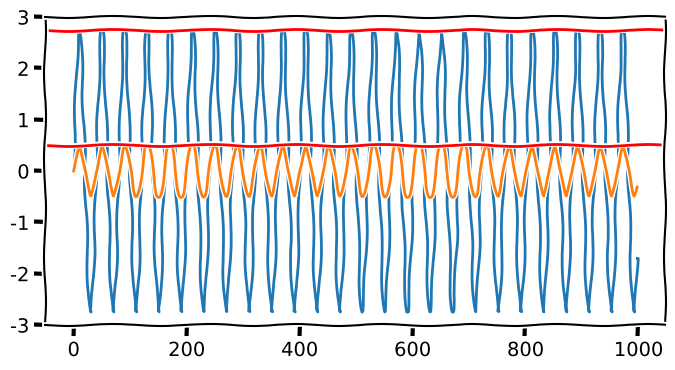

In [ ]:
def peak_amplitude(data):
    return np.max(data)

freq = 550
(t,audio1) = generate_sinusoid(amp = 2.75, freq=freq, dur=3)
print('Peak amplitude = %2.2f ' % peak_amplitude(audio1))
(t,audio2) = generate_sinusoid(amp = 0.5, freq=freq, dur=3)
print('Peak amplitude = %2.2f ' % peak_amplitude(audio2))

# We can see how this works visually
plt.figure(figsize=(8,4))
plt.ylim((-3, 3))

plt.plot(audio1[0:999])
plt.plot(audio2[0:999])
plt.axhline(y=peak_amplitude(audio1), color='r', linestyle='-')
plt.axhline(y=peak_amplitude(audio2), color='r', linestyle='-')
print("Estimated amplitude", peak_amplitude(audio1))
print("Estimated amplitude", peak_amplitude(audio2))

We now have a way of measuring the amplitude of sinusoidal signal from an array of digital samples. In more realistic situations when analyzing music and sounds there will not be a single sinusoidal signal but rather combinations of them as well as interferring noise and sounds.Let's look at what happens when we use the peak amplitude estimation method when some noise is added to our input. **An important observation is that as humans we can still hear clearly the sinusoid signal despite the presence of the interferring noise.** The peak amplitude estimation in this more challenging situation is basically useless.


In [ ]:
noise = np.random.normal(0, 0.75, len(audio1))
mix = audio1 + noise

def mix_plot(audio, interference, mix, amplitude_function):
  plt.rcParams["figure.figsize"] = (20,8)
  fig, (ax1, ax2, ax3) = plt.subplots(1,3)
  ax1.set_ylim((-8, 6))
  ax1.plot(audio, label='audio')
  ax1.plot(interference, label = 'interference', alpha=0.6)
  ax1.legend(loc='lower left')

  ax2.set_ylim((-8,6))
  ax2.plot(mix, label = 'mix', alpha=0.8)
  ax2.plot(audio, label='audio')
  ax2.legend(loc='lower left')

  ax3.set_ylim((-8,6))
  ax3.plot(audio, label='audio')
  ax3.plot(mix, label = 'mix', alpha=0.6)
  ax3.plot(interference, alpha = 0.5, label='interference')
  ax3.axhline(y=amplitude_function(mix), color='r', linestyle='-', label='estimated amplitude')
  ax3.axhline(y=amplitude_function(audio), color='black', linestyle='-', label='true amplitude')
  ax3.legend(loc='lower left')

mix_plot(audio1[0:999], noise[0:999], mix[0:999], peak_amplitude)
print('Actual amplitude = %2.2f ' % peak_amplitude(audio1[0:999]))
print('Peak amplitude = %2.2f ' % peak_amplitude(mix[0:999]))

ipd.Audio(mix, rate=srate)

NameError: name 'np' is not defined

# RMS amplitude estimation

So the peak amplitude estimation seems quite sensitive to the interferring noise. Intuititively this makes sense as there we consider only one sample of the array to perform the estimation. A more robust way would be to consider each sample of the arrray for the amplitude estimation. A common approach used in DSP is to perform RMS (Root Mean Squarred) amplitude estimation. The equation for RMS is:

$$
RMS = \sqrt{\vphantom{A^1} \frac{1}{N}\sum_{n=0}^{N-1} x[n]^2}
$$


For the mathematically inclined you can show why in the code below there is a square root of 2 factor in the RMS amplitude estimation of a sinusoid. To do so substitute $x[n]$ with $A \sin(\omega t)$ and then take the integral corresponding to the sum in the continuous case. For the programming inclined create a plot of the original signal and then the squarred signal and visually consider what is the average power of the squarred signal.

In [ ]:
def rms_amplitude(data):
    rms_sum = np.sum(np.multiply(data,data))
    rms_sum /= len(data)
    return np.sqrt(rms_sum) * np.sqrt(2.0)

print('RMS amplitude = %2.2f ' % rms_amplitude(audio1[0:999]))
print('RMS amplitude = %2.2f ' % rms_amplitude(mix[0:999]))

audio_product = np.multiply(audio1[0:999],audio1[0:999])
plt.figure()
plt.ylim((-8, 8))
plt.plot(audio2[0:999], label = 'mix')
plt.plot(audio_product, label='product')
plt.axhline(y=np.mean(audio_product) * np.sqrt(2.0), color='r', linestyle='-', label='average of the squarred signal')
plt.axhline(y=np.sqrt(np.mean(audio_product)) * np.sqrt(2.0), color='black', linestyle='-', label='RMS estimate')
plt.legend(loc='lower left')

audio_product = np.multiply(mix[0:999],mix[0:999])
plt.figure()
plt.ylim((-10, 15))
plt.plot(mix[0:999], label = 'mix')
plt.plot(audio_product, label='product')
plt.axhline(y=np.mean(audio_product) * np.sqrt(2.0), color='r', linestyle='-', label='average of the squared signal')
plt.axhline(y=np.sqrt(np.mean(audio_product)) * np.sqrt(2.0), color='black', linestyle='-', label='RMS estimate')
plt.legend(loc='lower left')

mix_plot(audio1[0:999], noise[0:999], mix[0:999], rms_amplitude)


NameError: name 'audio1' is not defined

So RMS amplitude estimation is more robust to interference than peak amplitude estimation but starts not working well when the amplitude of the interferring noise is larger as one can observe below.  

In [ ]:
noise = np.random.normal(0, 1.5, len(audio1))
mix = audio2 + noise

print('RMS amplitude = %2.2f ' % rms_amplitude(audio2[0:999]))
print('RMS amplitude = %2.2f ' % rms_amplitude(mix[0:999]))

mix_plot(audio2[0:999], noise[0:999], mix[0:999], rms_amplitude)


ipd.Audio(mix, rate=srate)

## Correlation-based amplitude estimation (dot-product)

To deal more robustly with interference we will have to make some additional assumption to perform amplitude estimation of sinusoidal signal. The additional assumption will be that we know the frequency and phase of the sinusoidal signal that we are trying to estimate the amplitude. Even though this scenario is more restrictive the knowledge of the frequency and phase of what we are looking forward will help us develop a very robust amplitude estimation method.

By knowing the frequency we can reliably estimate the amplitude in much more challenging conditions. To do so we will be utilizing the dot product between two signals/arrays which is defined as:

$$
<x,y> = \sum_{n=0}^{N-1} x[n] * y[n]
$$

Knowing the frequency $\omega$ we are trying to estimate the amplitude for we can create a "probe" sinusoid of the same frequency $\omega$ and unit amplitude. Taking the dot product of our input signal which has other interferring sounds with the "probe" sinusoid will allow us to robustly estimate the amplitude of that sinusoid. **Important note:** this works only if both the sinusoids that is burried with other sounds and the "probe" sinusoids have the same phase. Later on we will use the term "basis" for this "probe" sinusoid of unit amplitude and matching phase.

Correlation is way to describe the similarity between two signal shapes. If the two signals considered are standarized (i.e their mean is set ot 0 and their standard devition to 1) their correlation is equal to their dot-produce.


In [ ]:
def dot_amplitude_freq(audio, freq):
    dur = audio.shape[0] / srate
    # create the probe/basis sinusoid for the right frequency
    (t,basis) = generate_sinusoid(freq=freq, dur=dur, amp = 1)
    dot_product = np.dot(audio, basis)
    return 2 * (dot_product / len(audio))

freq = 550
print('Dot amplitude = %2.2f ' % dot_amplitude_freq(audio1, freq))
print('Dot amplitude = %2.2f ' % dot_amplitude_freq(mix, freq))


plt.figure()
plt.ylim((-7, 6))
plt.plot(mix[0:999], label = 'mix')
plt.plot(noise[0:999], alpha = 0.2, label='noise')
plt.plot(audio2[0:999], label='audio')

plt.axhline(y=dot_amplitude_freq(mix[0:999], freq), color='r', linestyle='-', label='estimated amplitude')
plt.axhline(y=dot_amplitude_freq(audio2[0:999], freq), color='black', linestyle='-', label='true amplitude')
plt.legend(loc='lower left')


Let's try to see visually how this dot-product amplitude estimation given a frequency of interest works. The orange plot is the multiplication of the input signal with the probe signal. The average of the point-wise multiplication result is the red line. In this case it corresponds to half the amplitude so we scale by 2 to get the dot-product amplitude estimation.

In [ ]:
dur = audio1.shape[0] / srate
(t,basis) = generate_sinusoid(freq=freq, dur=dur, amp = 1)

audio_product = np.multiply(audio1[0:999],basis[0:999])
basis = basis[0:999]
plt.figure()
plt.ylim((-4, 4))
plt.plot(audio1[0:999], label = 'audio')
plt.plot(basis, label='basis')
plt.legend(loc='lower left')


plt.figure()
plt.ylim((-4, 4))
plt.plot(audio_product, label='audio product')
plt.axhline(y=np.mean(audio_product), color='r', linestyle='-', label='average of the point-wise multiplication with basis')
plt.axhline(y=2 * np.mean(audio_product), color='black', linestyle='-', label='dot-product amplitude estimate')
plt.legend(loc='lower left')

NameError: name 'audio1' is not defined

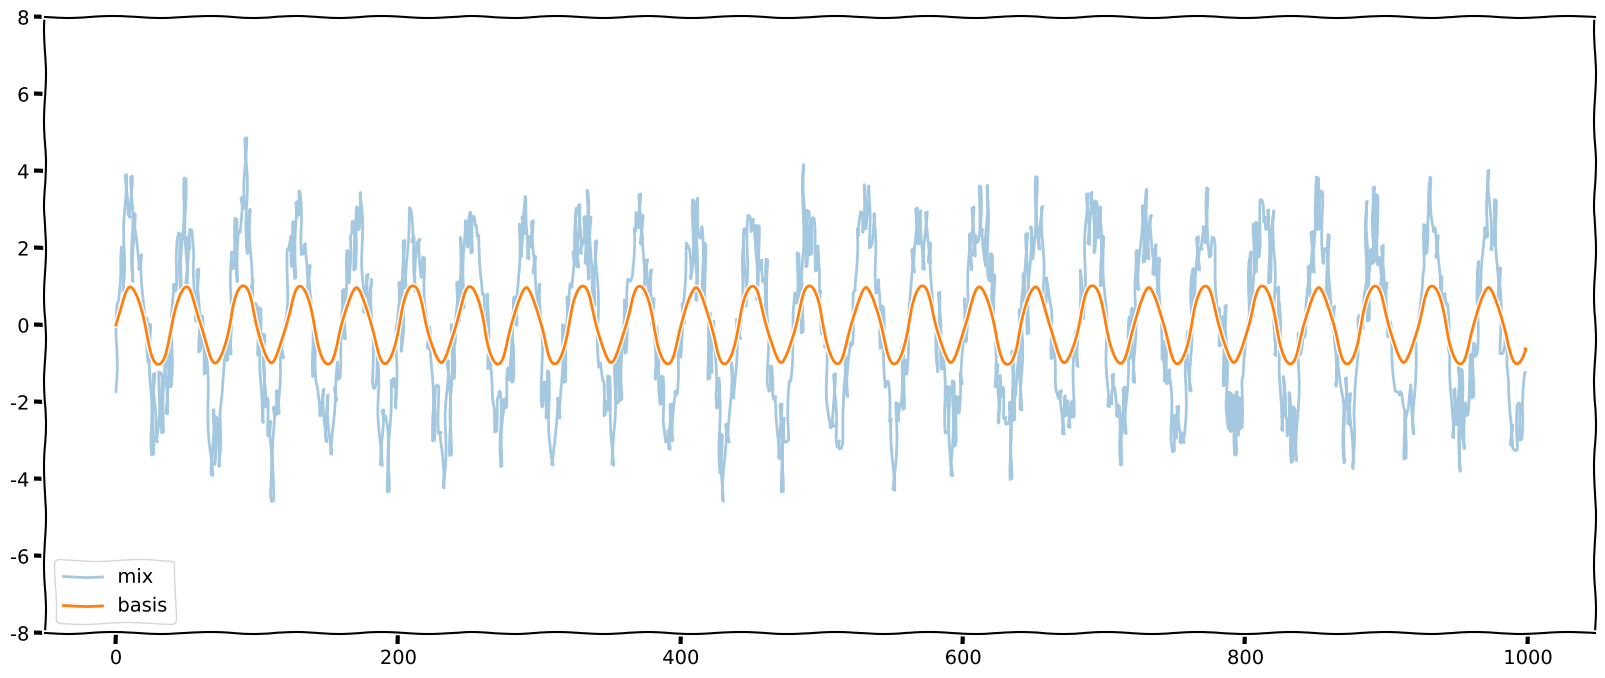

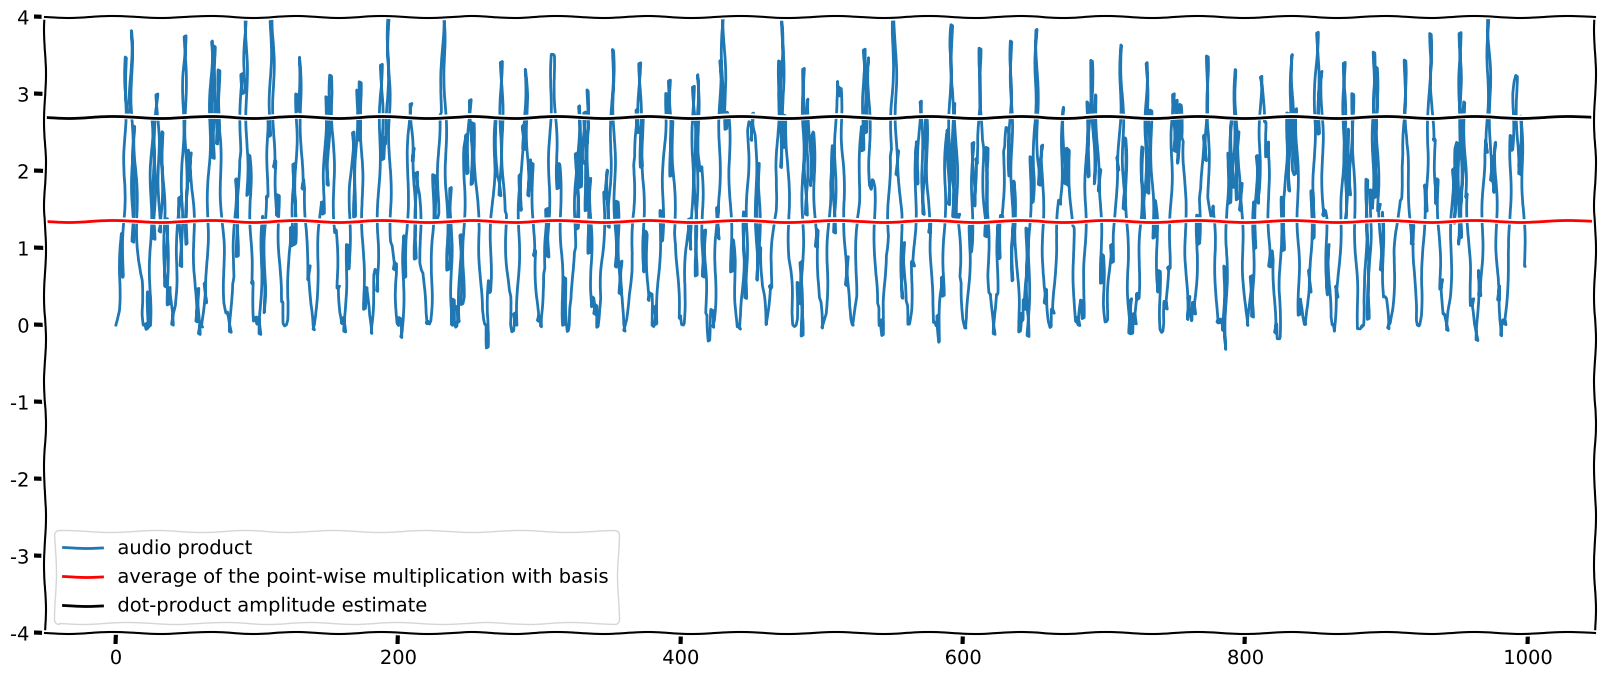

In [ ]:
dur = audio1.shape[0] / srate
(t,basis) = generate_sinusoid(freq=freq, dur=dur, amp = 1)
basis = basis[0:999]
audio_product = np.multiply(mix[0:999],basis[0:999])
plt.figure()
plt.ylim((-8, 8))
plt.plot(mix[0:999], label = 'mix', alpha=0.4)
plt.plot(basis, label='basis')

plt.legend(loc='lower left')
plt.figure()
plt.ylim((-4, 4))
plt.plot(audio_product, label='audio product')

plt.axhline(y=np.mean(audio_product), color='r', linestyle='-', label='average of the point-wise multiplication with basis')
plt.axhline(y=2 * np.mean(audio_product), color='black', linestyle='-', label='dot-product amplitude estimate')
plt.legend(loc='lower left')

Now let's consider some other interference scenarios in which instead of noise we have a music recording acting as interference. **Notice that we are still able as human listeners to clearly hear the sinusoid while we hear the trumpet sound.**


In [ ]:
filename = librosa.ex('trumpet')
trumpet, sr = librosa.load(filename)
trumpet = 16.0 * trumpet[0:audio2.shape[0]]
print(trumpet.shape)
print(audio1.shape)
mix = audio1 + trumpet
ipd.Audio(mix, rate=srate)

(66150,)
(66150,)


Dot amplitude = 2.75 
Dot amplitude = 2.75 


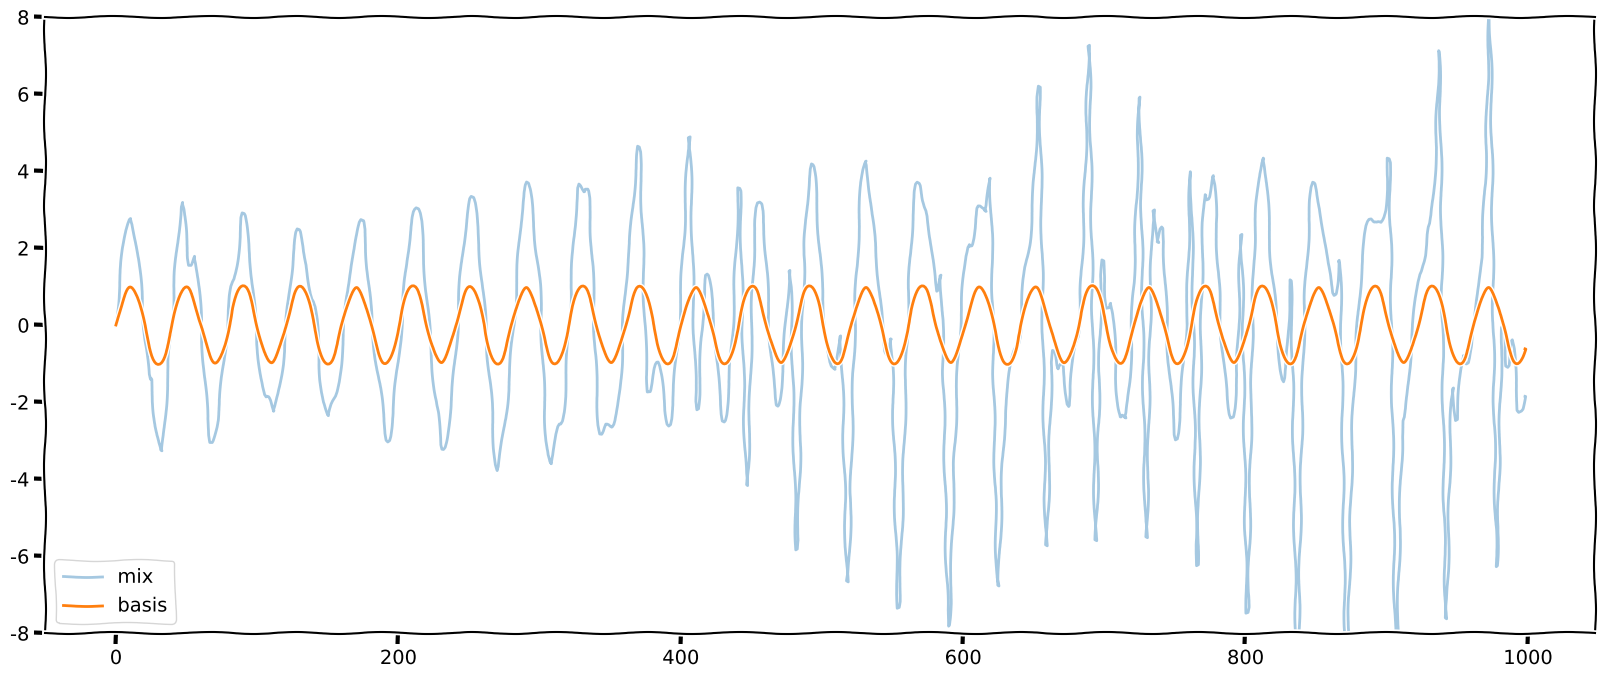

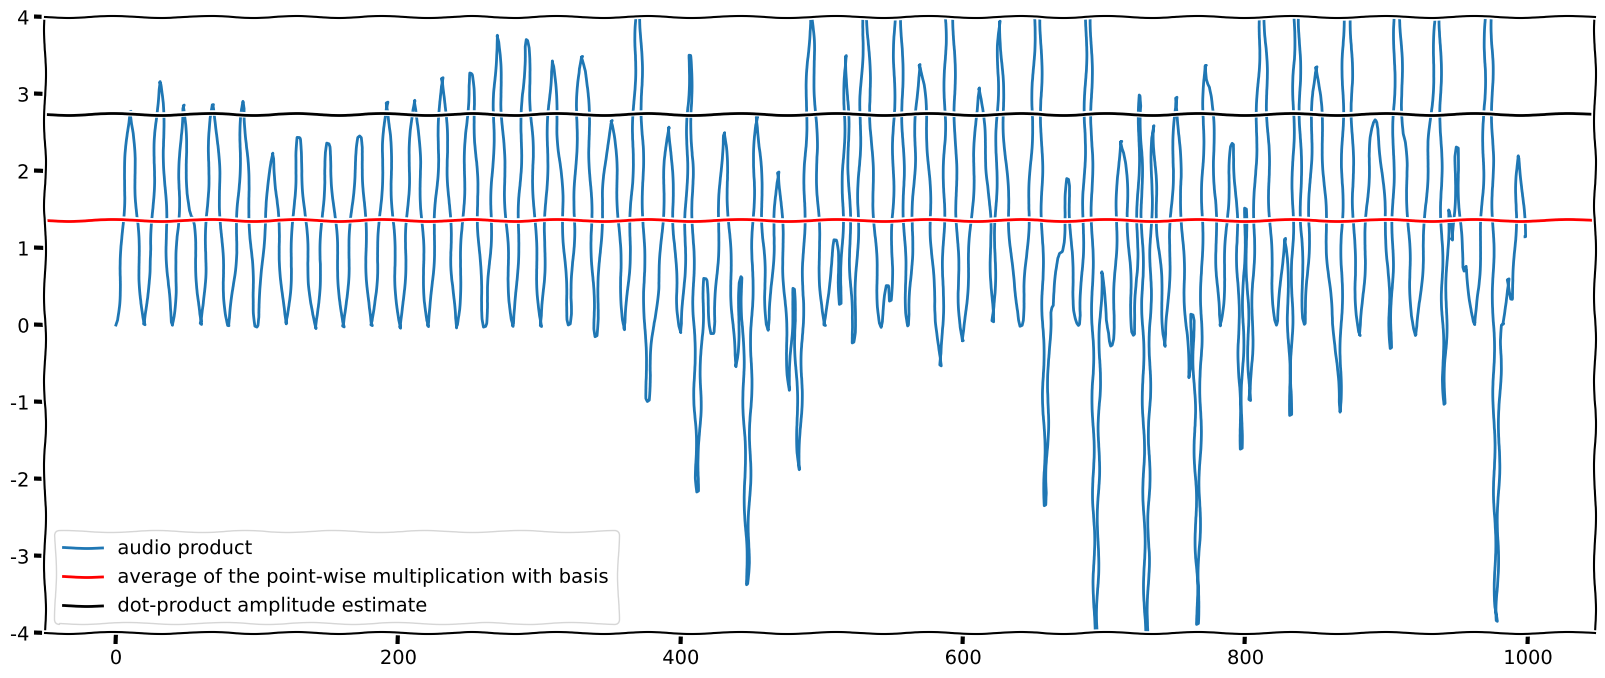

In [ ]:
print('Dot amplitude = %2.2f ' % dot_amplitude_freq(audio1, freq))
print('Dot amplitude = %2.2f ' % dot_amplitude_freq(mix, freq))
dur = audio1.shape[0] / srate
(t,basis) = generate_sinusoid(freq=freq, dur=dur, amp = 1)

audio_product = np.multiply(mix[0:999],basis[0:999])
plt.figure()
plt.ylim((-8, 8))
plt.plot(mix[0:999], label = 'mix', alpha=0.4)
plt.plot(basis[0:999], label='basis')
plt.legend(loc='lower left')
plt.figure()
plt.ylim((-4, 4))

plt.plot(audio_product, label='audio product')

plt.axhline(y=np.mean(audio_product), color='r', linestyle='-', label='average of the point-wise multiplication with basis')
plt.axhline(y=2 * np.mean(audio_product), color='black', linestyle='-', label='dot-product amplitude estimate')
plt.legend(loc='lower left')

**Exercise for the reader** - experiment with the dot-product estimation with the input being a simple additive combination of sinusoidal signals. Generate
a sound consisting of three sinusoids with harmonically-related frequencies
and random amplitudes. Use three "probe" basis sinusoids with the same frequencies and unit amplitude as the mixture sound to estimate the random amplitudes from the mixture sound.The creation of a sound from adding harmonically related sinusoids is called additive synthesis.


# PART 3 Dealing with Phase and Time

So far we have assumed that the unit amplitude basis (or probe) sinusoidal signal that we use for the dot-product amplitude estimation is in phase with the sinusoidal signal for which we are trying to estimate the amplitude. Let's see what can happen if that assumption does not hold i.e the basis and the original sinusoidal signal have the same frequency but different phases.
It is clear that our correlation (dot-product) based amplitude estimation does not work when the phases of the basis (probe) and the signal in the input mixture are not aligned.


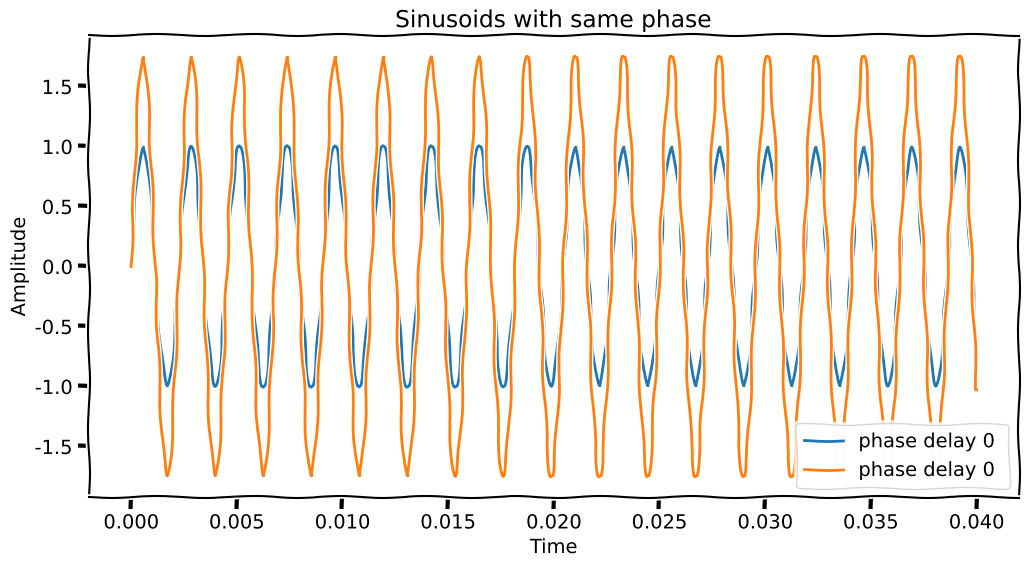

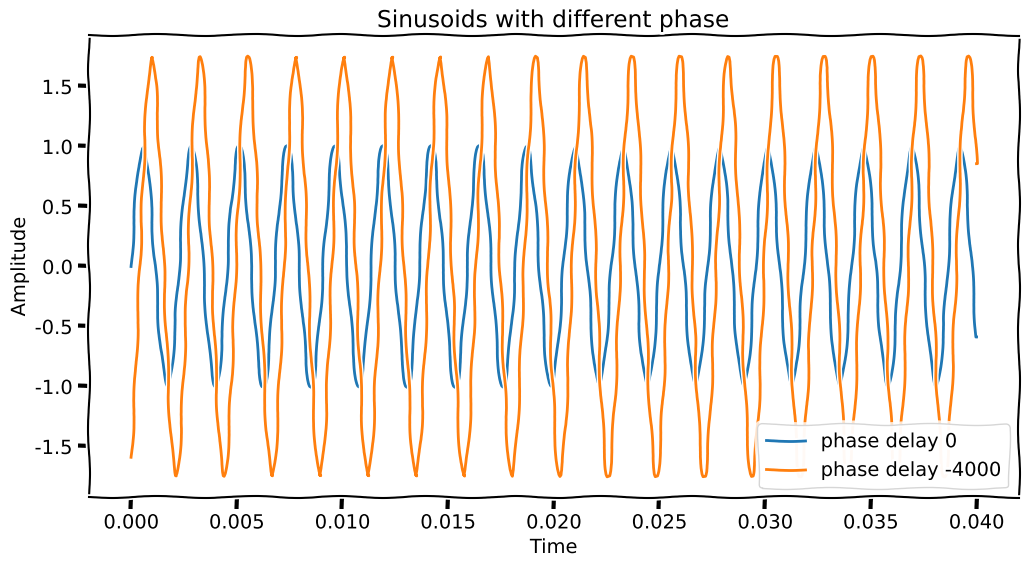

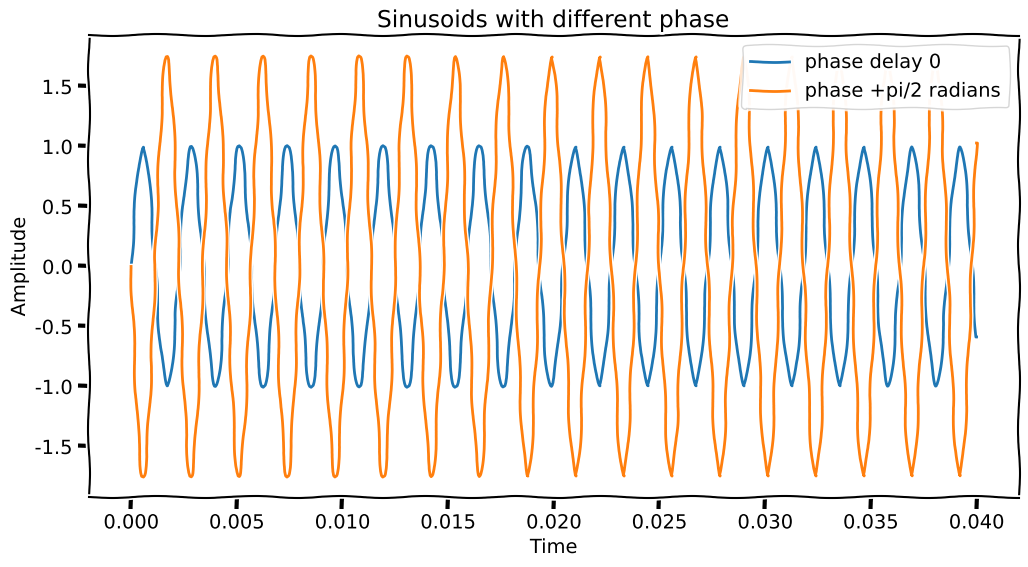

In [ ]:

(t,probe) = generate_sinusoid(freq = 440, dur = 0.04,amp = 1.0, phase = 0.0)
(t,data1) = generate_sinusoid(freq = 440, dur = 0.04,amp = 1.75, phase = 0.0)
(t,data2) = generate_sinusoid(freq = 440, dur = 0.04,amp = 1.75, phase = -4000 * (2 * np.pi / srate))
(t,data3) = generate_sinusoid(freq = 440, dur = 0.04,amp = 1.75, phase = np.pi)

fig = plt.figure(figsize=(12,6))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Sinusoids with same phase')
plt.plot(t, probe, t, data1)
plt.legend(['phase delay 0 ', 'phase delay 0'])
plt.show()

fig = plt.figure(figsize=(12,6))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Sinusoids with different phase')
plt.plot(t, probe, t, data2)
plt.legend(['phase delay 0 ', 'phase delay -4000'])
plt.show()

fig = plt.figure(figsize=(12,6))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Sinusoids with different phase')
plt.plot(t, probe, t, data3)
plt.legend(['phase delay 0 ', 'phase +pi/2 radians'])
plt.show()


As you can see if the sinusoid for which we are trying to estimate the amplitude does not have the same phase as the basis unit amplitude probe sinusoid then the amplitude estimation does not work. Visually you can understand this by looking at the plots and realizing that only when the two sinusoids are aligned in terms of phase they correlate appropriately to perform the amplitude estimation. Let's see if that's the case. When the probe is not aligned in terms of phase our amplitude estimation does not work any more.


In [ ]:
print(dot_amplitude_freq(data1, 440.0))
print(dot_amplitude_freq(data2, 440.0))
print(dot_amplitude_freq(data3, 440.0))


1.7412241565660342
0.7216382461773138
-1.7412241565660342


So now we have a robust way of estimating the amplitude of a sinusoid of a given frequency but it requires phase alignment between the basis probe signal of the frequency we are looking for . One idea that actually does work is to try different phase shifts and select the one that provides the highest/best amplitude estimation. Once we find the "best" shift we can adjust basis with unit amplitude to align with the complex sound and thus get the right amplitude estimation. However, this approach comes with a high-cost. The operation of sliding the inner-products by different shifts is called a **cross-correlation **and is costly to perform for many shifts. For the case of sinusoids Using some math we will see we can avoid this tedious brute-force approach and perform reliable amplitude estimation using only two inner products.


Estimated shift (samples) for audio1 (no shift)=  54
Estimated shift (samples) for audio2 (shifted by 2000)  =  2007
Estimated shift (samples) for audio3 (shift by -1000) =  -944


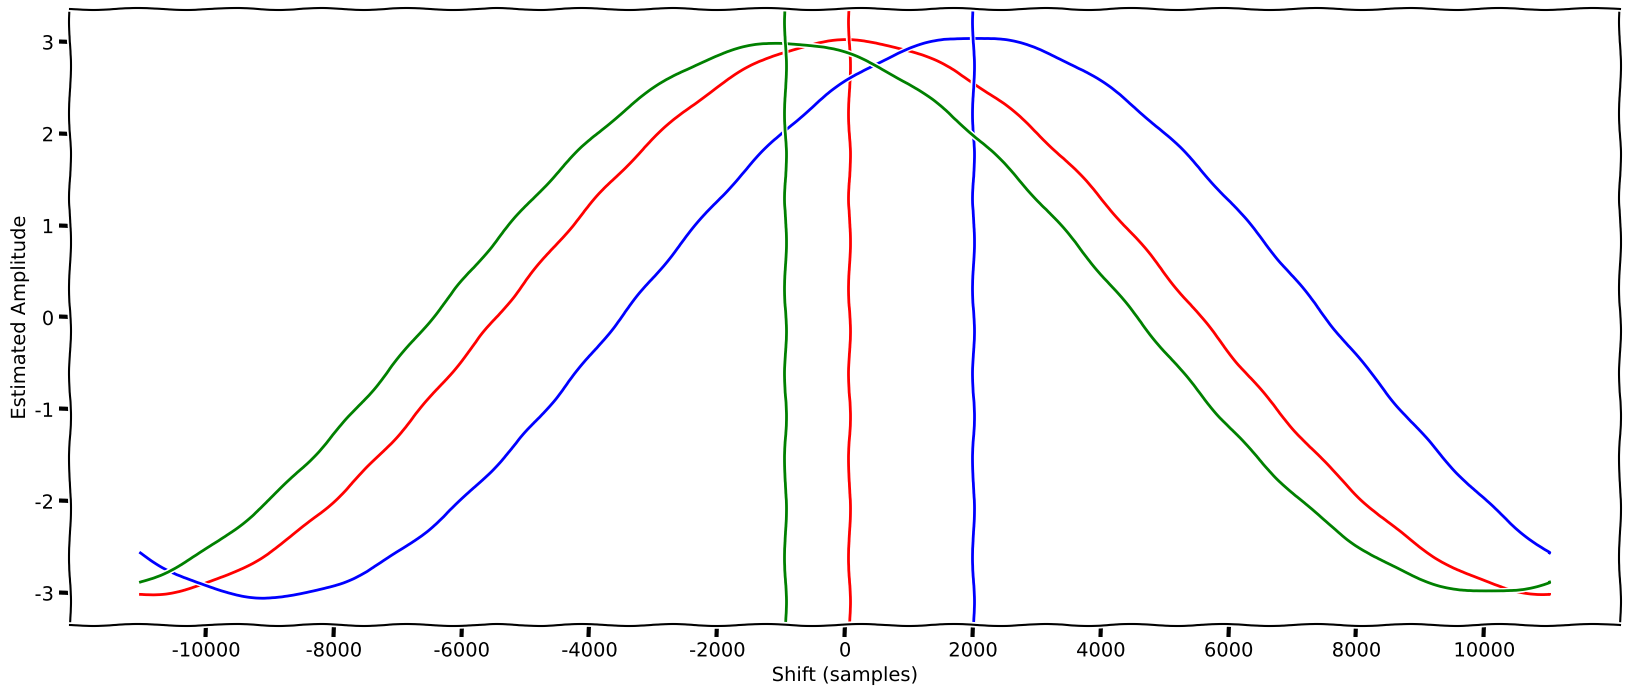

Amplitude estimate when aligned with basis = 3.0151762461331812
Amplitude estimate without alignment audio2 = 2.56383810401335
Amplitude estimate for audio 2 with aligned probe = 3.0487819310917823


Amplitude estimate when aligned with basis = 3.0151762461331812
Amplitude estimate without alignment data3 = 2.880459900728853
Amplitude estimate with alignment data3 = 2.9879543223837834


In [ ]:
def dot_amplitude(audio, basis):
    dur = audio.shape[0] / srate
    dot_product = np.dot(audio, basis)
    return 2 * (dot_product / len(audio))


def plot_amp_phases(data1, srate, color):
    amplitude_estimates = np.zeros(srate)
    shifts = np.arange(-int(srate/2), int(srate/2))
    # calculate the amplitude_estimate for different integer shifts (delays)
    for k in shifts:
        (t, data2) = generate_sinusoid(freq=440, dur = 0.02, amp = 1.0, phase = k * (2 * np.pi / srate))
        amplitude_estimates[k+int(srate/2)] = dot_amplitude(data1,data2)
    plt.plot(shifts, amplitude_estimates, color=color)
    # return the location of the highest peak as an estimate of the appropriate shift
    plt.axvline(x=shifts[np.argmax(amplitude_estimates)], color=color, linestyle='-')
    plt.ylabel("Estimated Amplitude")
    plt.xlabel("Shift (samples)")

    return shifts[np.argmax(amplitude_estimates)]


srate = 22050

k = 0
(t,probe) = generate_sinusoid(freq=440, dur = 0.02,amp = 1.0, phase = 0)
(t,audio1) = generate_sinusoid(freq=440, dur = 0.02,amp = 3.0, phase = 0)

shift_audio1 = plot_amp_phases(audio1, srate, 'red')
print('Estimated shift (samples) for audio1 (no shift)= ', shift_audio1)

(t,audio2) = generate_sinusoid(freq=440, dur = 0.02,amp = 3.0, phase = 2000 * (2 * np.pi / srate))
shift_audio2 = plot_amp_phases(audio2, srate, 'blue')
print('Estimated shift (samples) for audio2 (shifted by 2000)  = ', shift_audio2)

(t,audio3) = generate_sinusoid(freq=440, dur = 0.02,amp = 3.0, phase = -1000 * (2 * np.pi / srate))
shift_audio3 = plot_amp_phases(data4, srate, 'orange')
print('Estimated shift (samples) for audio3 (shift by -1000) = ', shift_audio3)
plot_amp_phases(data4, srate, 'green')

plt.xticks(np.arange(-10000, 11000, 2000))
plt.grid()
plt.show()

print('Amplitude estimate when aligned with basis =', dot_amplitude(probe, audio1))
print('Amplitude estimate without alignment audio2 =', dot_amplitude(probe, audio2))
(t,probe_shifted) = generate_sinusoid(freq=440, dur = 0.02,amp = 1.0, phase = shift_audio2 * (2 * np.pi / srate))
print('Amplitude estimate for audio 2 with aligned probe =', dot_amplitude(probe_shifted, audio2))
print('\n')

print('Amplitude estimate when aligned with basis =', dot_amplitude(probe, audio1))
print('Amplitude estimate without alignment data3 =', dot_amplitude(probe, audio3))
(t,probe_shifted) = generate_sinusoid(freq=440, dur = 0.02,amp = 1.0, phase = shift_audio3 * (2 * np.pi / srate))
print('Amplitude estimate with alignment data3 =', dot_amplitude(probe_shifted, audio3))

Notice a couple of things about the code above. The resolution for the different shift is one sample. We can imagine scenarios in which we will
need more accurate phases that would correspond to a fractional delay. Another observation is that we can either shift the basis/probe after estimating the shift or shift the signal - the result would be the same. Finally you can see that the shift estimation is not exactly accurate but it does give a reasonble approximation.

Doing the cross-products for every possible time shift is also computationally heavy and you notice the delay in computing the output of this cell. We can make things a bit faster by vectorizing the loops and computing less shifts at the expense of amplitude estimation accuracy.

Estimated shift for audio1 =  275
Estimated shift for audio2 =  2227
Estimated shift for audio3 =  -721


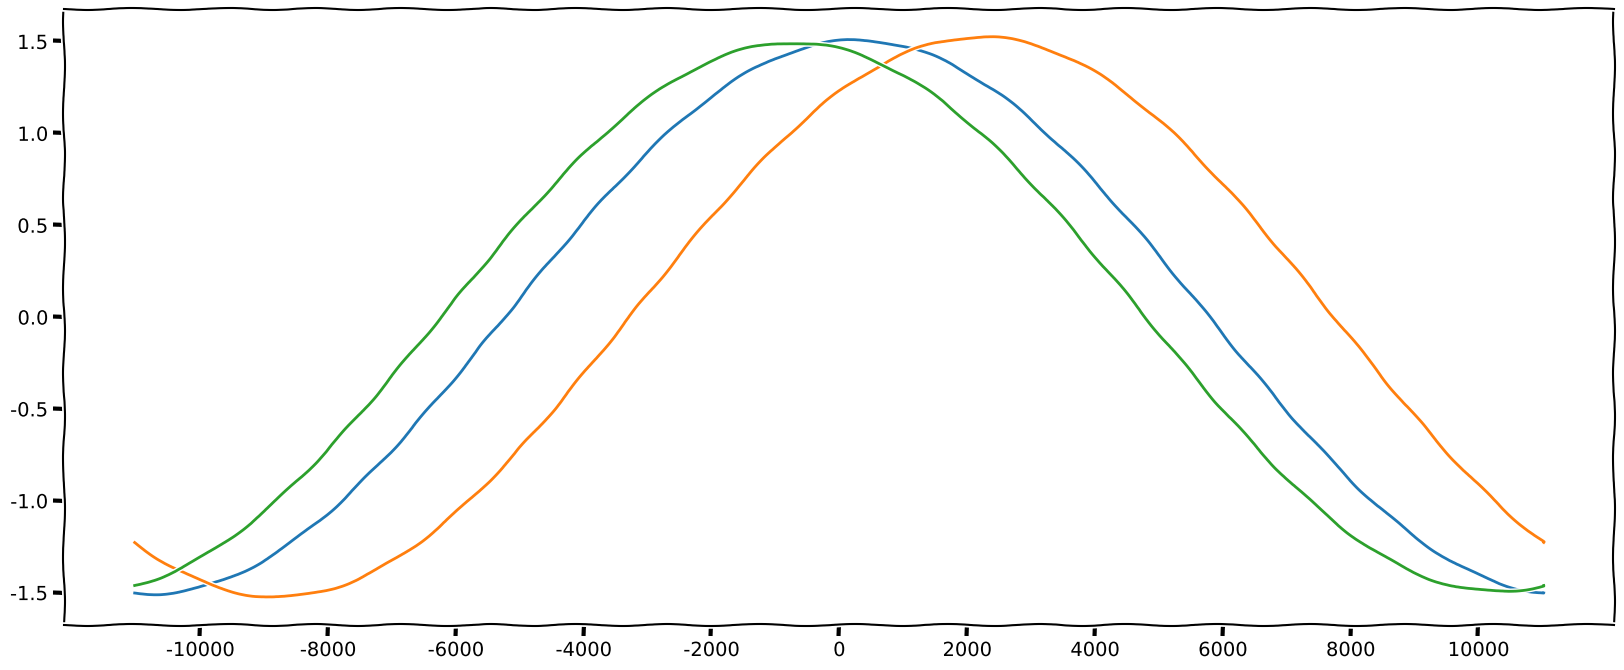

Amplitude estimate when aligned with basis = 3.0151762461331812
Amplitude estimate without alignment audio2 = 2.56383810401335
Amplitude estimate for audio 2 with aligned probe = 3.042770757457799


Amplitude estimate when aligned with basis = 3.0151762461331812
Amplitude estimate without alignment data3 = 2.880459900728853
Amplitude estimate with alignment data3 = 2.9879543223837834


In [ ]:
def plot_amp_phases_vectorized(data1, srate, step_size):
    # 1. Define shifts and time array once
    shifts = np.arange(-int(srate / 2), int(srate / 2), step_size)
    t = np.linspace(0, len(data1)/srate, int(len(data1)), endpoint=False) # standard time array for 0.02s

    # 2. Calculate phase vector (shape: [num_shifts, 1])
    phases = (shifts * (2 * np.pi / srate))[:, np.newaxis]

    # 3. Create 2D array of sinusoids via broadcasting (shape: [num_shifts, num_samples])
    data2_matrix = np.sin(2 * np.pi * 440 * t + phases)

    # 4. Vectorize the amplitude estimation step
    # Example assuming amplitude_estimate is cross-correlation or dot product normalized:
    # amplitude_estimates = np.dot(data2_matrix, data1) / len(data1)
    # OR if using a custom vector-compatible amplitude function:
    amplitude_estimates = np.dot(data2_matrix, data1) / len(data1)
    plt.plot(shifts, amplitude_estimates)

    return shifts[np.argmax(amplitude_estimates)]


srate = 22050
k = 0
step_size = 4

(t,probe) = generate_sinusoid(freq=440, dur = 0.02,amp = 1.0, phase = 0)
(t,audio1) = generate_sinusoid(freq=440, dur = 0.02,amp = 3.0, phase = 0)

shift_audio1 = plot_amp_phases_vectorized(audio1, srate, step_size)
print('Estimated shift for audio1 = ', shift_audio1)

(t,audio2) = generate_sinusoid(freq=440, dur = 0.02,amp = 3.0, phase = 2000 * (2 * np.pi / srate))
shift_audio2 = plot_amp_phases_vectorized(audio2, srate, step_size)
print('Estimated shift for audio2 = ', shift_data3)

(t,audio3) = generate_sinusoid(freq=440, dur = 0.02,amp = 3.0, phase = -1000 * (2 * np.pi / srate))
shift_data4 = plot_amp_phases_vectorized(audio3, srate, step_size)
print('Estimated shift for audio3 = ', shift_data4)

plt.xticks(np.arange(-10000, 11000, 2000))
plt.grid()
plt.show()


print('Amplitude estimate when aligned with basis =', dot_amplitude(probe, audio1))
print('Amplitude estimate without alignment audio2 =', dot_amplitude(probe, audio2))
(t,probe_shifted) = generate_sinusoid(freq=440, dur = 0.02,amp = 1.0, phase = shift_audio2 * (2 * np.pi / srate))
print('Amplitude estimate for audio 2 with aligned probe =', dot_amplitude(probe_shifted, audio2))
print('\n')

print('Amplitude estimate when aligned with basis =', dot_amplitude(probe, audio1))
print('Amplitude estimate without alignment data3 =', dot_amplitude(probe, audio3))
(t,probe_shifted) = generate_sinusoid(freq=440, dur = 0.02,amp = 1.0, phase = shift_audio3 * (2 * np.pi / srate))
print('Amplitude estimate with alignment data3 =', dot_amplitude(probe_shifted, audio3))

In [ ]:
def cross_correlation_amplitude(data, freq, srate, step_size):
    # 1. Define shifts and time array once
    shifts = np.arange(-int(srate / 2), int(srate / 2), step_size)
    t = np.linspace(0, len(data)/srate, int(len(data)), endpoint=False) # standard time array

    # 2. Calculate phase vector (shape: [num_shifts, 1])
    phases = (shifts * (2 * np.pi / srate))[:, np.newaxis]

    # 3. Create 2D array of sinusoids via broadcasting (shape: [num_shifts, num_samples])
    data2_matrix = np.sin(2 * np.pi * freq * t + phases)

    # 4. Vectorize the amplitude estimation step
    # Example assuming amplitude_estimate is cross-correlation or dot product normalized:
    # amplitude_estimates = np.dot(data2_matrix, data1) / len(data1)
    # OR if using a custom vector-compatible amplitude function:
    amplitude_estimates = np.dot(data2_matrix, data) / len(data)
    return 2 * np.max(amplitude_estimates)

step_size = 4
print('Cross-correlation amplitude estimate =', cross_correlation_amplitude(data1, 440.0, srate, step_size))
print('Cross-correlation amplitude estimate =', cross_correlation_amplitude(data2, 440.0, srate, step_size))
print('Cross-correlation amplitude estimate =', cross_correlation_amplitude(data3, 440.0, srate, step_size))
print('Cross-correlation amplitude estimate =', cross_correlation_amplitude(data4, 440.0, srate, step_size))



Tangent: Dichotic pitch, create stimulus, cross-correlation, delay and multiply/sum


In [ ]:
def create_triangle(freq=440, amp=1.0, dur=1.0, srate=44100):
# Generates a triangular wave signa
  t = np.arange(0,dur,1.0/srate)
  output = np.zeros_like(t)
  for n in range(1,12,2):
    sign = (-1) ** ((n-1)/2)
    sinusoid = sign * (1.0/(n**2)) * np.sin(2 * np.pi * n*freq * t)
    output += sinusoid
  return (t, amp * (8/(np.pi**2)) * output)

(t, audio) = create_sinusoid(freq = 440, amp = 0.75, dur=1, srate=srate)
(t, probe) = create_sinusoid(freq = 440, amp = 1.0, dur =1, srate=srate)

print('Dot amplitude = %2.2f ' % dot_amplitude_sinusoid(audio, probe))
ipd.Audio(audio, rate=srate)

def dot_amplitude_triangle(data1, data2):
    dot_product = np.dot(data1, data2)
    return 3 * (dot_product / len(data1))

(t, audiot) = create_triangle(freq = 440, amp = 0.75, dur=1, srate=srate)
(t, probet) = create_triangle(freq = 440, amp = 1.0, dur =1, srate=srate)
print('Dot amplitude = %2.2f ' % dot_amplitude_triangle(audiot, probet))

def dot_amplitude(data1, data2):
    dot_product = np.dot(data1, data2)
    k = np.mean(data2 ** 2)
    return (dot_product / len(data1) / k)

(t, audiot) = create_triangle(freq = 440, amp = 0.75, dur=1, srate=srate)
(t, probet) = create_triangle(freq = 440, amp = 1.0, dur =1, srate=srate)
print('Dot amplitude = %2.2f ' % dot_amplitude(audiot, probet))


NameError: name 'create_sinusoid' is not defined

# Dealing with time

So far we have discussed amplitude estimation using the dot-product approach of looking for a specific frequency in our mixture of sounds signal. What if we have as input a signal that changes over time (for example the simple melody played by sinusoidal oscillators) ? The typical way to deal with this is what is called short-time processing. Basically we process the audio signal in shorter chunks of samples (typically called windows or frames). Each chunk must be long enough to contain at least one cycle of our signal of interest but short enough that the frequency we are interested in remains present during the chunk. For now the chunks will be processed will not be overlapping but later we will see how overlapping can be used.

Let's say that we process the sound in chunks of 1024 samples. For each
chunk we can estimate the amplitude of a particular frequency of interest. For the toy example below we will use three notes or pitches playing the simple melody. We can then estimate through analysis the amplitude "envelope" of each of these notes. This can be considered as a very basic and simplified form of music transcription, the process of converting audio and discrete music symbols that provide instructions of how the music can be performed.





In [ ]:
import scipy.signal as signal

# frequencies of three notes (C, D, E)
c_freq = 523.0
d_freq = 587.0
e_freq = 659.0

# generate sine signals corresponding to each note
(t,c_data) = create_sinusoid(freq = c_freq, dur = 0.5, amp = 0.5, srate = srate)
(t,d_data) = create_sinusoid(freq = d_freq, dur = 0.5, amp = 0.5)
(t,e_data) = create_sinusoid(freq = e_freq, dur = 0.5, amp = 0.5)

# form a simple melody by concateneting the signal arrays for each note
melody = np.hstack([c_data, d_data, e_data, c_data, c_data, d_data, e_data, c_data])
ipd.Audio(melody,rate=srate, normalize=False)



NameError: name 'create_sinusoid' is not defined

We will now perform short-time process to our melody and extract 3 amplitude envelopes. Notice that we can easily reconstruct the original audio from
the short chunks that we cut it into.


In [ ]:
%%time

# This will take a few seconds
hopSize = 1024
winSize = 1024
offsets = np.arange(0, len(melody), hopSize)

output = np.zeros(len(melody))
c_amplitudes = []
d_amplitudes = []
e_amplitudes = []
print("Length of offsets:", len(offsets))

# Note that we use a big step size to consider less phase shift - otherwise
# this process will take too long
step_size = 64
for (m,o) in enumerate(offsets):
    frame = melody[o:o+winSize]
    if len(frame) < winSize:
          break  # Ignore incomplete segment
    c_amplitudes.append(cross_correlation_amplitude(frame, c_freq, srate, step_size))
    d_amplitudes.append(cross_correlation_amplitude(frame, d_freq, srate, step_size))
    e_amplitudes.append(cross_correlation_amplitude(frame, e_freq, srate, step_size))
    output[o:o+winSize] += frame
ipd.Audio(output, rate=srate)


Length of offsets: 1
CPU times: user 680 µs, sys: 0 ns, total: 680 µs
Wall time: 677 µs


/usr/local/lib/python3.12/dist-packages/IPython/lib/display.py:174: RuntimeWarning: invalid value encountered in divide
  scaled = data / normalization_factor * 32767
/usr/local/lib/python3.12/dist-packages/IPython/lib/display.py:175: RuntimeWarning: invalid value encountered in cast
  return scaled.astype("<h").tobytes(), nchan


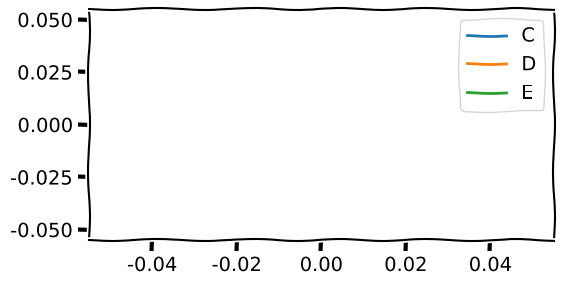

In [ ]:
t = np.arange(1, len(c_amplitudes)+1)
fig = plt.figure(figsize=(6,3))
plt.plot(t, c_amplitudes)
plt.plot(t, d_amplitudes)
plt.plot(t, e_amplitudes)
plt.legend(['C', 'D', 'E'])
plt.show()


# Dealing with mismatch between probe frequency and actual frequency

Let's take a look at what happens if there is a mismatch between the probe frequency and the actual frequency of the signal. As you can see very close frequencies can get a reasonable amplitude estimate but the accuracy of this estimation drops quickly as we move away from the basis/probe frequency.

In [ ]:
def dot_amplitude_sinusoid(data1, data2):
    dot_product = np.dot(data1, data2)
    return 2 * (dot_product / len(data1))

est_amplitudes = []

freq_range = np.arange(195, 205, 0.25 )
for f in freq_range:
  (t, audio) = create_sinusoid(freq = f, amp = 0.75, dur=0.2, srate=srate)
  (t, probe) = create_sinusoid(freq = 200, amp = 1.0, dur =0.2, srate=srate)
  est_amp = dot_amplitude(audio, probe)
  est_amplitudes.append(est_amp)
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.plot(freq_range, est_amplitudes)
plt.show()

est_amplitudes = []
freq_range = np.arange(170, 230, 1 )
for f in freq_range:
  (t, audio) = create_sinusoid(freq = f, amp = 0.75, dur=0.2, srate=srate)
  (t, probe) = create_sinusoid(freq = 200, amp = 1.0, dur =0.2, srate=srate)
  est_amp = dot_amplitude(audio, probe)
  est_amplitudes.append(est_amp)

plt.plot(freq_range, est_amplitudes)
plt.xlabel('Frequency')
plt.ylabel('Amplitude')
plt.show()

NameError: name 'create_sinusoid' is not defined

## Does cross-correlation amplitude estimation work for a different periodic signal ?





## Estimating phase using just two sinusoidal probes

There is a simpler approach to estimating both the amplitude and the phase of a sinusoidal signal of known frequency. This approach will allow us estimate an arbitrary phase without having to try many possible shfits but simply calculating the dot products with two probe/basis signals.

It is based on the following identity:
\begin{equation} a \sin(x) + b \cos(x) = R \sin (x + \theta)
\end{equation}
where
$ R = \sqrt{(a^2 + b^2)} \;\; \text{and} \;\; \theta = \tan^{-1} \frac{b}{a} $

So basically we can represent a sinusoidal signal of a particular amplitude and phase as a weighted sum (with appropriate weights $ a \;\; \text{and}\;\; b$ of a sine signal and a cosine signal). So to estimate the amplitude and phase of a sinusoid of known frequency we can take the inner product with a pair of sine and cosine probe/basis signals of the same frequncy. Let's see how this would work. We will see later that these pairs of sines and cosine signals are what are called basis functions of the Discrete Fourier Transform (DFT).

In [ ]:
def dot_amplitude(data1, data2):
    dot_product = np.dot(data1, data2)
    return 2 * (dot_product / len(data1))

rate = 8000
amplitude = 3.0
k = 1000
phase = k * (2 * np.pi / srate)
print('Original amplitude  = %2.2f' % amplitude)
print('Original phase = %2.2f' % phase)

(t,data) = create_sinusoid(freq=300, dur = 0.5, amp =amplitude, phase = phase)
plt.plot(data[1:1000])
(t,basis_sin) = create_sinusoid(freq=300, dur=0.5, amp = 1)
(t,basis_cos) = create_sinusoid(freq=300, dur=0.5, amp = 1, phase = np.pi/2)
plt.plot(basis_sin[1:1000])
plt.plot(basis_cos[1:1000])

# we take to dot-products of our input signal - one with the sin basis function
# and one with the cos basis function. Together these two estimates a and b are used to
# estimate both the amplitude/magnitude and the phase

a = dot_amplitude(data, basis_sin)
b = dot_amplitude(data, basis_cos)


estimated_phase = np.arctan(b/a)
estimated_magnitude = np.sqrt(a*a+b*b)

print('Estimated Magnitude = %2.2f' % estimated_magnitude)
print('Estimated Phase = %2.2f' % estimated_phase)

Original amplitude  = 3.00
Original phase = 0.28


NameError: name 'create_sinusoid' is not defined

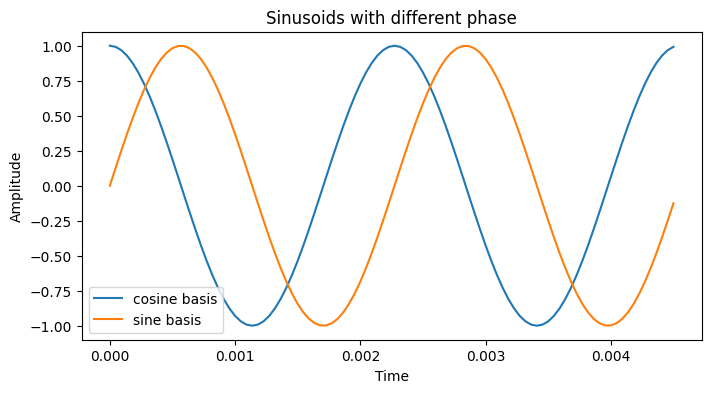

a = 0.04670768288021
b = 3.0151762461331812
Amp = 3.015537995596444
Angle =  1.5553067024720995


a = 2.5638381040133504
b = 1.6497895523224968
Amp = 3.048781951951178
Angle =  0.5717811136311433


a = 2.880459900728853
b = -0.7942429223618904
Amp = 2.9879543268645903
Angle =  -0.26904918397462924




In [ ]:
srate = 22050

(t,data0) = create_sinusoid(freq = 440, dur = 0.02,amp = 1.0, phase = np.pi/2)
(t,data1) = create_sinusoid(freq = 440, dur = 0.02,amp = 1.0, phase = 0)

fig = plt.figure(figsize=(8,4))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Sinusoids with different phase')
plt.plot(t[0:100], data0[0:100], t[0:100], data1[0:100])
plt.legend(['cosine basis', 'sine basis'])
plt.show()

imaginary = dot_amplitude(data1, data2)
real = dot_amplitude(data0, data2)

a = real
b = imaginary
print('a =', a)
print('b =', b)
print('Amp =', np.sqrt(a*a+b*b))
print('Angle = ', np.arctan2(b,a))
print('\n')

a = amplitude_estimate(data1, data3)
b = amplitude_estimate(data0, data3)
print('a =', a)
print('b =', b)
print('Amp =', np.sqrt(a*a+b*b))
print('Angle = ', np.arctan2(b,a))

print('\n')

a = amplitude_estimate(data1, data4)
b = amplitude_estimate(data0, data4)
print('a =', a)
print('b =', b)
print('Amp =', np.sqrt(a*a+b*b))
print('Angle = ', np.arctan2(b,a))

print('\n')



So let's recap. If we are looking for the amplitude of a sinusoidal signal that is part of a complex signal and we know it's frequency we can take use inner-products of array corresponding to the complex signal that contains our "burried" sinusoid with two basis arrays (or probes) one containing a sampled sine signal of the known frequency and one containing a sampled cosine signal of the known frequency.
The resulting estimates which we call "real" and "imaginary" can be combined to return an estimate of the mangitude of the sinusoid as well as an estimate of the phase. Each of these sinusoids can be considered a "probe" or "basis" and is a building block that can take as input a complex input signal consisting of multiple sinusoidal signals and potentially other interferring sounds and estimate reliably the amplitude and the phase of of a sinusoid with a particular frequency of interest.




# Exploring the Discrete Fourier Transform  

### George Tzanetakis, University of Victoria

In this notebook we will explore the Discrete Fourier Transform which is a fundamental algorithm in Digital Signal Processing. First let's look at the mathematical notation:

\begin{equation}
X_k = <x, e^{jtk2\pi /N}> = \sum_{t=0}^{N-1} x_t e^{-j t k 2 \pi/N}  
\end{equation}

We start with a finite, length-N segment of a digital signal $x_0, x_1, \dots, x_{N-1}$. We define the inner product as expected:
\begin{equation}
<x,y> = \sum_{t=0}^{N-1} x_t y_t^*
\end{equation}
and the corresponding basis is N frequency phasors equally spaced in the desired rage from zero to the sampling frequency:
\begin{equation}
{e^{jtk2\pi/N}} = {cos(tk2\pi/N) + j sin(tk2\pi/N})\;\;\; \text{for} \;\; 0 \leq k \leq N-1
\end{equation}

In [ ]:
def plot_basis(t, x_re, x_im):
    # plot them
    plt.figure(figsize=(20,5))
    plt.subplot(121)
    plt.plot(t, x_re, lw=2, color='blue')
    plt.subplot(122)
    plt.plot(t, x_im, lw=2, color='red')

N = 512
t = np.arange(0,N)

# basis function real and imaginary parts for k=4
k = 1
x_re = np.cos(k*t*2*np.pi/N)
x_im = np.sin(k*t*2*np.pi/N)
plot_basis(t, x_re, x_im)

k = 4
x_re = np.cos(k*t*2*np.pi/N)
x_im = np.sin(k*t*2*np.pi/N)
plot_basis(t, x_re, x_im)

In [ ]:
# basis function real and imaginary parts for k=10
k = 10
x_re = np.cos(k*t*2*np.pi/N)
x_im = np.sin(k*t*2*np.pi/N)

plot_basis(t, x_re, x_im)

\begin{equation}
X_k = <x, e^{jtk2\pi /N}> = \sum_{t=0}^{N-1} x_t e^{-j t k 2 \pi/N}  = \sum_{t=0}^{N-1} x_t cos(tk2\pi/N) + \sum_{t=0}^{N-1} x_t  j sin(tk2\pi/N)
\end{equation}

Looking at the equation above you can see that for a specific k the complex spectrum value X_k can be computed by taking two inner products for the input signal $x_t$ with the real and imaginary parts of the corresponding basis function.

Let's consider as input a cosine signal of the same frequency as a particular pair of basis functions let's say with $k=4$ and look at the signal resulting from the point-wise multiplication of the input with the real part and the imagine part. As you can see the point-wise multiplication with the real part results in a signal that is centered above zero and therefore the inner product is positive (the value is shown with the straight black line in the plot). The point-wise multiplication with the imaginary part results in a signal that is centered at zero and therefore the inner product is zero (the value is shown with the straight black line in the plot). Recall from before when we examined using the inner product with a sinusoid of known frequency to estimate amplitude that the estimated amplitude is simply twice the inner product.

In [ ]:
def plot_product(t,x1,x2):
    prod = np.multiply(x1,x2)
    inner_prod = np.sum(prod) / len(prod)
    plt.figure(figsize=(20,5))
    plt.plot(t, x1,'.', lw=1, color='blue')
    plt.plot(t, x2,'.', lw=1, color='cyan')
    plt.plot(t, np.multiply(x1,x2), lw=4, color='red')
    ip_line = np.empty(len(prod))
    ip_line.fill(inner_prod)
    plt.plot(t, ip_line, lw=4, color='black')
    plt.plot(t, ip_line*2, lw=2, color='black')
    plt.legend(('x', 'x_basis', 'point-wise product', 'inner product', 'amplitude estimate'), loc='upper right')


k=4
a = 0.6
x = a * np.cos(k*t*2*np.pi/N)
x_re = np.cos(k*t*2*np.pi/N)
x_im = np.sin(k*t*2*np.pi/N)
plot_product(t,x,x_re)
plot_product(t,x,x_im)

When the input is a sine wave the inner product with the real part of the basis is zero and the inner product with the imaginary part of the basis is positive.

In [ ]:

x = a * np.sin(k*t*2*np.pi/N)
plot_product(t,x,x_re)
plot_product(t,x,x_im)


Now let's consider the case of using as input a sinusoidal signal of different frequency let's say corresponding to k=10. As you can observe in this case the inner products with both the real and imaginary part of the basis functions are zero.

In [ ]:
k=10
x = a * np.sin(k*t*2*np.pi/N)
plot_product(t,x,x_re)
plot_product(t,x,x_im)

Now consider an input that is a mixure of two sinsoids. Notice that we are still able to correctly estimate the amplitude of the mixture component that corresponds to the basis function we are using.

In [ ]:
k=4
a1 = 0.8
x1 = a1 * np.sin(k*t*2*np.pi/N)
a2 = 0.4
k = 10
x2 = a2 * np.sin(k*t*2*np.pi/N)
x = x1+x2
plot_product(t,x,x_re)
plot_product(t,x,x_im)

Finally lets look at computing the Discrete Fourier Transform directly from the equation and viewing the magnitude spectrum for the mixture signal we examined above. The code is written so that the connection to measuring amplitude and phases using inner products with the real and imaginary parts of each basis element is emphasized and the code does not utilize the complex number type. Notice the normalization by 2/N so that the mangitude spectrum shows the estimated amplitudes of the input signal.

In [ ]:
def pedagogical_dft(x, N):
    X_re = np.zeros(N)       # array holding the real parts of the spectrum
    X_im = np.zeros(N)       # array holding the imaginary values of the spectrum
    for k in np.arange(0,N):
        for t in np.arange(0,N):
            X_re[k] += x[t] * np.cos(t * k * 2 * np.pi / N)   # inner product with real basis k
            X_im[k] += x[t] * np.sin(t * k * 2 * np.pi / N)   # inner product with imaginary basis k
    return (X_re, X_im)

def plot_mag_spectrum(Xmag):
    plt.figure(figsize=(20,5))
    n = np.arange(0,len(Xmag))
    plt.plot(n,Xmag)

N = 512
n = np.arange(0,N)

# Single sinusoid
k=100
x1 = 1.5 * np.sin(k*n*2*np.pi/N)

(X_re, X_im) = pedagogical_dft(x1, N)
Xmag = 2 * np.sqrt(X_re * X_re + X_im * X_im) /N
plot_mag_spectrum(Xmag)

In [ ]:
# Mixture sinusoid input
x2 = np.sin(50*n*2*np.pi/N) + 0.5 * np.sin(100 * n * 2 * np.pi/N) + 0.3 * np.sin(300 * n * 2 * np.pi/N)

(X_re, X_im) = pedagogical_dft(x2, N)
Xmag = 2 * np.sqrt(X_re * X_re + X_im * X_im) / N
plot_mag_spectrum(Xmag)


In [ ]:
X = np.fft.fft(x1)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag)

X = np.fft.fft(x2)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag)

In [ ]:
%%time
import numpy as np
import timeit

def pedagogical_dft(x, N):
    X_re = np.zeros(N)       # array holding the real parts of the spectrum
    X_im = np.zeros(N)       # array holding the imaginary values of the spectrum
    for k in np.arange(0,N):

        for t in np.arange(0,N):
            X_re[k] += x[t] * np.cos(t * k * 2 * np.pi / N)   # inner product with real basis k
            X_im[k] += x[t] * np.sin(t * k * 2 * np.pi / N)   # inner product with imaginary basis k
    return (X_re, X_im)

def test():
    x = np.zeros(512)
    for i in range(10):
      pedagogical_dft(x,512)

test()

In [ ]:
%%time
import numpy as np
import timeit

def test():
    for i in range(10):
      x = np.zeros(512)
      np.fft.fft(x)

test()

In [ ]:
filename = librosa.ex('fishin')
fishin, sr = librosa.load(filename)
ipd.Audio(fishin, rate=sr)

In [ ]:
import scipy.fft as fft
import random

y = trumpet[0:100000]
#y = fishin[0:10000]
complex_spectrum = fft.rfft(y)

magnitude_spectrum = np.abs(complex_spectrum)
print(len(complex_spectrum))
bin = 10

#mags = magnitude_spectrum[bin:bin+10000]
#magnitude_spectrum = np.zeros(len(magnitude_spectrum))
#magnitude_spectrum[bin:bin+10000] = mags

#magnitude_spectrum = np.roll(np.abs(complex_spectrum), -1000)
magnitude_spectrum = np.ones(len(magnitude_spectrum))
# magnitude_spectrum = np.abs(complex_spectrum)
phase_spectrum = np.angle(complex_spectrum)
# phase_spectrum[0:int(len(magnitude_spectrum))] = np.random.uniform(0, 2*np.pi, int(len(magnitude_spectrum)))

reconstructed_complex_spectrum  = magnitude_spectrum*(np.cos(phase_spectrum)+1j*np.sin(phase_spectrum))
reconstructed = fft.irfft(reconstructed_complex_spectrum)
fig = plt.figure(figsize=(6,2))
plt.xlabel("Time in samples")
plt.ylabel("Amplitude")
plt.plot(reconstructed[0:1000], lw=2, color='blue')
plt.plot(y[0:1000], lw=2, color='blue')

plt.show()
ipd.Audio( reconstructed,rate=sr, normalize=True)



In [ ]:
a = np.concatenate([reconstructed, reconstructed, reconstructed], axis=0)
print(a.shape)

In [ ]:
ipd.Audio(a,rate=sr, normalize=True)

In [ ]:
import scipy.signal as signal
audio_signal = trumpet
hopSize = 256
winSize = 1024
offsets = np.arange(0, len(audio_signal), hopSize)

output = np.zeros(len(audio_signal))
spectrogram = []
times = []
for (m,o) in enumerate(offsets):
    frame = audio_signal[o:o+winSize]
    if len(frame) < winSize:
            break  # Ignore incomplete segment
    window = signal.windows.hann(len(frame))
    mag_spectrum = np.abs(np.fft.fft(frame)[:winSize // 2])
    spectrogram.append(mag_spectrum)
    frame = window * frame
    output[o:o+winSize] += frame
    times.append((o + winSize) / sr)

spectrogram = np.array(spectrogram).T
frequencies = np.fft.fftfreq(winSize, d=1/sr)[:winSize // 2]

ipd.Audio(output, rate=sr)

In [ ]:
a = [1, 2, 4,5, 6]
print(a[:3])
winSize = 1024
print(winSize /2)
print(winSize // 2)

In [ ]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, frequencies, 10 * np.log10(spectrogram + 1e-10), shading='gouraud', cmap='viridis')
#plt.pcolormesh(times, frequencies, spectrogram, shading='gouraud', cmap='viridis')

plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.title('Spectrogram')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [ ]:
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, frequencies, spectrogram, shading='gouraud', cmap='viridis')
#plt.pcolormesh(times, frequencies, spectrogram, shading='gouraud', cmap='viridis')

plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.title('Spectrogram')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [ ]:
import scipy.signal as signal
audio_signal = trumpet
hopSize = 1 * 512
winSize = 1 * 4096
offsets = np.arange(0, len(audio_signal), hopSize)

output = np.zeros(len(audio_signal))
spectrogram = []
times = []
for (m,o) in enumerate(offsets):
    frame = audio_signal[o:o+winSize]
    if len(frame) < winSize:
            break  # Ignore incomplete segment
    window = signal.windows.hann(len(frame))
    windows = np.ones(len(frame))
    #mag_spectrum = np.abs(np.fft.fft(frame)[:winSize // 2])
    #spectrogram.append(mag_spectrum
    complex_spectrum = np.fft.fft(window*frame)
    mag_spectrum = np.abs(complex_spectrum)
    sorted_mag_spectrum = np.sort(mag_spectrum)
    threshold = sorted_mag_spectrum[-4]
    mag_spectrum[mag_spectrum < threshold] = 0
    #spectrogram.append(mag_spectrum)
    #mag_spectrum = np.ones(len(frame))
    phase_spectrum = np.angle(complex_spectrum)
    phase_spectrum[0:int(len(mag_spectrum))] = np.random.uniform(0, 2*np.pi, int(len(mag_spectrum)))
    #phase_spectrum = np.zeros(len(mag_spectrum))

    reconstructed_complex_spectrum  = mag_spectrum*(np.cos(phase_spectrum)+1j*np.sin(phase_spectrum))
    reconstructed_frame = np.real(fft.ifft(reconstructed_complex_spectrum))

    reconstructed = window * reconstructed_frame
    output[o:o+winSize] += reconstructed_frame
    times.append((o + winSize) / sr)

spectrogram = np.array(spectrogram).T
frequencies = np.fft.fftfreq(winSize, d=1/sr)[:winSize // 2]
ipd.Audio(output, rate=sr)

In [ ]:
import soundfile as sf
def plot_mag_spectrum(Xmag):
    plt.figure(figsize=(20,5))
    n = np.arange(0,len(Xmag))
    plt.plot(n,Xmag)

# load a C4 sine wave
x,srate = sf.read('sineC4.wav')
print(np.max(x))
ipd.Audio(x,rate=srate)

In [ ]:
N = len(x)
X = np.fft.fft(x)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag)

In [ ]:
# load a C4 sine wave - notice that there are multiple peaks
# corresponding to the harmonics
x,srate = sf.read('cl_C4.wav')
print(np.max(x))
ipd.Audio(x,rate=srate)
ipd.Audio(x,rate=srate)

In [ ]:
N = len(x)
X = np.fft.fft(x)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag)

In [ ]:
# let's zoom to the first 5000 values to see the harmonics better
plot_mag_spectrum(Xmag[1:5000])

In [ ]:
# load a 3 second excerpt from a jazz recording
x, srate = sf.read('freddie3sec.wav')
ipd.Audio(x,rate=srate)

In [ ]:
N = len(x)
X = np.fft.fft(x)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag)
plot_mag_spectrum(Xmag[1:5000])

In [ ]:
def plot_mag_spectrum(Xmag, N):
    plt.figure(figsize=(20,5))
    n = np.arange(0,len(Xmag))
    plt.xlabel('Frequency as DFT bin')
    plt.plot(n,Xmag)

    plt.figure(figsize=(20,5))
    n = np.linspace(0.0, len(Xmag) *1.0 /N, num=len(Xmag))
    plt.xlabel('Frequency in fractions of sampling rate')
    plt.plot(n,Xmag)

    plt.figure(figsize=(20,5))
    n = np.linspace(0.0, (len(Xmag) *1.0 / N)*44100, num=len(Xmag))
    plt.xlabel('Frequency in Hz ')

    plt.plot(n,Xmag)

# load a C4 sine wave
x, srate = sf.read('freddie3sec.wav')
N = len(x)
X = np.fft.fft(x)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag[1:5000], len(Xmag) )

In [ ]:
# load a C4 sine wave
x, srate = sf.read('sineC4.wav')
N = len(x)
X = np.fft.fft(x)
Xmag = 2 * np.abs(X) / N
plot_mag_spectrum(Xmag[1:1000], N)
Xmag = Xmag[1:1000]

In [ ]:
fractions   = np.linspace(0.0, len(Xmag) *1.0 /N, num=len(Xmag))
frequencies = np.linspace(0.0, (len(Xmag) *1.0 / N)*44100, num=len(Xmag))

# find the index (dft bin) of the peak
peak_bin = np.argmax(Xmag)
print('Index in bins: ', peak_bin)
print('Index in fractions of sampling rate', fractions[peak_bin])
print('Index in Hz: ', frequencies[peak_bin])
peak_freq = frequencies[peak_bin]
peak_midi = int(69 + 12*np.log2(peak_freq/440.))
print(peak_midi)